In [19]:
using LinearAlgebra, Parameters, Serialization, Plots

# Define parameters
Base.@kwdef struct Params
    left_x_BC::String = "traction" # or " Dirichlet"
    right_x_BC::String = "traction" # or " Dirichlet"
    y_BC::String = "traction_free" # "Neumann" or "traction_free"
    k::Float64 = 1e-8       # small numerical factor
    λ::Float64 = 1.0
    μ::Float64 = 1.0
    Lx::Float64 = 1.0
    Nx::Int = 15
    Δx::Float64 = Lx/(Nx-1) # spatial step
    Ly::Float64 = 1.0
    Ny::Int = 16
    Δy::Float64 = Ly/(Ny-1) # spatial step
    T::Int = 10 + 1         # number of steps for pseudotime
    dt::Float64 = 1/(T-1)   # step in pseudotime
    tol::Float64 = 1e-6     # convergence tolerance
    max_iter::Int = 10      # max staggered iterations
    savefile::String = "runs/sol.jls" # file to save iterations
    l::Float64 = 0.1 # regularization length for phase field
    C3::Float64 = 1.0 # constant for phase field eq.
    """ 
    parameter for star-convex energy split
    with γstar>=-1, γstar=-1 is standard model and γstar=0 -s volumetric-deviatoric split
    """
    γstar::Float64 = 0.0
    simple_d::Bool = false # solve the phase field eq w/ ∂^2 (false) or drop ∂^2 (true) 
end

Params

In [20]:
# ------------------------------------------------------------
# Grid indexing (column major)
# ------------------------------------------------------------
lin(i,j,Nx) = i + (j-1)*Nx

# ------------------------------------------------------------
# Derivatives (1st order boundary, 2nd interior)
# ------------------------------------------------------------
function Dx(f,i,j,p::Params)
    Nx = p.Nx
    Δx = p.Δx
    if i == 1
        return (f[i+1,j] - f[i,j]) / Δx
    elseif i == Nx
        return (f[i,j] - f[i-1,j]) / Δx
    else
        return (f[i+1,j] - f[i-1,j]) / (2Δx)
    end
end

function Dy(f,i,j,p::Params)
    Ny = p.Ny
    Δy = p.Δy
    if j == 1
        return (f[i,j+1] - f[i,j]) / Δy
    elseif j == Ny
        return (f[i,j] - f[i,j-1]) / Δy
    else
        return (f[i,j+1] - f[i,j-1]) / (2Δy)
    end
end

function Dxx(f,i,j,p::Params)
    Nx = p.Nx
    Δx = p.Δx
    if i == 1
        return (f[1,j] - 2*f[2,j] + f[3,j]) / Δx^2
    elseif i == Nx
        return (f[Nx-2,j] - 2*f[Nx-1,j] + f[Nx,j]) / Δx^2
    else
        return (f[i-1,j] - 2*f[i,j] + f[i+1,j]) / Δx^2
    end
end

function Dyy(f,i,j,p::Params)
    Ny = p.Ny
    Δy = p.Δy
    if j == 1
        return (f[i,1] - 2*f[i,2] + f[i,3]) / Δy^2
    elseif j == Ny
        return (f[i,Ny-2] - 2*f[i,Ny-1] + f[i,Ny]) / Δy^2
    else
        return (f[i,j-1] - 2*f[i,j] + f[i,j+1]) / Δy^2
    end
end

# degradation function
function g(d,i,j,p::Params)
    return (1.0-d[i,j])^2 + p.k
end


g (generic function with 1 method)

In [21]:

# Build Q,P coefficients after linearization
function build_QP(d,a1_bar,a2_bar,p::Params)

    Nx = p.Nx
    Ny = p.Ny
    λ,μ = p.λ,p.μ

    Q111 = zeros(Nx,Ny)
    P111 = zeros(Nx,Ny)
    Q112 = zeros(Nx,Ny)
    P112 = zeros(Nx,Ny)

    Q121 = zeros(Nx,Ny)
    P121 = zeros(Nx,Ny)
    Q122 = zeros(Nx,Ny)
    P122 = zeros(Nx,Ny)

    Q221 = zeros(Nx,Ny)
    P221 = zeros(Nx,Ny)
    Q222 = zeros(Nx,Ny)
    P222 = zeros(Nx,Ny)

    for j in 1:Ny
        for i in 1:Nx

            a1barx  = Dx(a1_bar,i,j,p)
            a1bary  = Dy(a1_bar,i,j,p)
            a2barx  = Dx(a2_bar,i,j,p)
            a2bary  = Dy(a2_bar,i,j,p)

            # pressure
            pres = (a1barx + a2bary)
            # mask
            if pres <= 0 
                mp = 1.0 + p.γstar*(1.0 - g(d, i, j, p))
            else    
                mp = g(d, i, j, p)
            end

            # # from linearisation
            # fbar = sqrt((a1barx - a2bary)^2 + (a1bary + a2barx)^2)

            # if fbar == 0.0 # strictly
            #     r1x = 1/6 - 1/(2^(3/2))
            #     r1y = -1/(2^(3/2))
            #     r2x = -1/(2^(3/2))
            #     r2y = 1/6 + 1/(2^(3/2))
            # else
            #     r1x = 1/6 - (a1barx - a2bary)/(2fbar)
            #     r1y = -(a1bary + a2barx)/(2fbar)
            #     r2x = -(a1bary + a2barx)/(2fbar)
            #     r2y = 1/6 + (a1barx - a2bary)/(2fbar)
            # end

            # q1 = (a1barx + a2bary)/6 - 0.5*fbar
            # q2 = (a1barx + a2bary)/6 + 0.5*fbar
            # # masks
            # m_q1 = q1 <= 0 ? 1.0 : g(d, i, j, p)
            # m_q2 = q2 <= 0 ? 1.0 : g(d, i, j, p)

            # coefficients
            # for a1x
            Q111[i,j] = (λ + 2*μ/3)*mp + 4*g(d,i,j,p)*μ/3 #λ + 2*μ
            # for a1y
            #P111[i,j] = 
            # for a2x 
            Q112[i,j] = (λ + 2*μ/3)*mp
            # for a2y
            P112[i,j] = -2*g(d,i,j,p)*μ/3 #λ

            #Q121[i,j] = 
            P121[i,j] = g(d,i,j,p)*μ #μ 
            Q122[i,j] = g(d,i,j,p)*μ #μ
            #P122[i,j] = 

            Q221[i,j] = (λ + 2*μ/3)*mp - 2*g(d,i,j,p)*μ/3 # λ
            #P221[i,j] = 
            Q222[i,j] = (λ + 2*μ/3)*mp
            P222[i,j] = 4*g(d,i,j,p)*μ/3 # λ + 2*μ
        end
    end

    return Q111,P111,Q112, P112,
           Q121,P121,Q122,P122,
           Q221,P221,Q222,P222
end


build_QP (generic function with 1 method)

In [97]:
i = 1
j = 2 

# midpoints in x
# sigma_11
P111_i_mhalf_j = P111[i,j]
P111_i_phalf_j = 0.5*(P111[i,j] + P111[i+1,j])
Q111_i_mhalf_j = Q111[i,j]
Q111_i_phalf_j = 0.5*(Q111[i,j] + Q111[i+1,j])
P112_i_mhalf_j = P112[i,j]
P112_i_phalf_j = 0.5*(P112[i,j] + P112[i+1,j])
Q112_i_mhalf_j = Q112[i,j]
Q112_i_phalf_j = 0.5*(Q112[i,j] + Q112[i+1,j])
# sigma_12
P121_i_mhalf_j = P121[i,j]
P121_i_phalf_j = 0.5*(P121[i,j] + P121[i+1,j])
Q121_i_mhalf_j = Q121[i,j]
Q121_i_phalf_j = 0.5*(Q121[i,j] + Q121[i+1,j])
P122_i_mhalf_j = P122[i,j]
P122_i_phalf_j = 0.5*(P122[i,j] + P122[i+1,j])
Q122_i_mhalf_j = Q122[i,j]
Q122_i_phalf_j = 0.5*(Q122[i,j] + Q122[i+1,j])

# midpoints in y
# sigma_12
P121_i_j_mhalf = 0.5*(P121[i,j-1] + P121[i,j])
P121_i_j_phalf = 0.5*(P121[i,j]   + P121[i,j+1])
Q121_i_j_mhalf = 0.5*(Q121[i,j-1] + Q121[i,j])
Q121_i_j_phalf = 0.5*(Q121[i,j]   + Q121[i,j+1])
P122_i_j_mhalf = 0.5*(P122[i,j-1] + P122[i,j])
P122_i_j_phalf = 0.5*(P122[i,j]   + P122[i,j+1])
Q122_i_j_mhalf = 0.5*(Q122[i,j-1] + Q122[i,j])
Q122_i_j_phalf = 0.5*(Q122[i,j]   + Q122[i,j+1])
# sigma_22
P221_i_j_mhalf = 0.5*(P221[i,j-1] + P221[i,j])
P221_i_j_phalf = 0.5*(P221[i,j]   + P221[i,j+1])
Q221_i_j_mhalf = 0.5*(Q221[i,j-1] + Q221[i,j])
Q221_i_j_phalf = 0.5*(Q221[i,j]   + Q221[i,j+1])
P222_i_j_mhalf = 0.5*(P222[i,j-1] + P222[i,j])
P222_i_j_phalf = 0.5*(P222[i,j]   + P222[i,j+1])
Q222_i_j_mhalf = 0.5*(Q222[i,j-1] + Q222[i,j])
Q222_i_j_phalf = 0.5*(Q222[i,j]   + Q222[i,j+1])

174.99684166333333

In [102]:
Q122_i_phalf_j

80.77008076999999

In [ ]:
Δx = p.Δx
Δy = p.Δy
#test = -0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)*f1_left[j-1] -(Q121_i_mhalf_j/(Δx^2) + 0.25*(Q221_i_j_mhalf - Q221_i_j_phalf)/(Δx*Δy))*f1_left[j] + 0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)*f1_left[j+1] -(0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy))*f2_left[j-1] -(Q122_i_mhalf_j/(Δx^2) + 0.25*(Q222_i_j_mhalf - Q222_i_j_phalf)/(Δx*Δy))*f2_left[j] + 0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)*f2_left[j+1]
#test

#-0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)*f1_left[j-1]
#-(Q121_i_mhalf_j/(Δx^2) 
#+ (0.25*(Q221_i_j_mhalf - Q221_i_j_phalf)/(Δx*Δy))*f1_left[j]
# + 0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)*f1_left[j+1]
#-(0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy))*f2_left[j-1]
#-(Q122_i_mhalf_j/(Δx^2) + 0.25*(Q222_i_j_mhalf - Q222_i_j_phalf)/(Δx*Δy))*f2_left[j]
# + 0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)*f2_left[j+1]

# -(Q111_i_mhalf_j/(Δx^2) + 0.25*(Q121_i_j_mhalf - Q121_i_j_phalf)/(Δx*Δy))*f1_left[j]

-726.93072693

In [64]:
# Build global matrix M and rhs b
function build_displacement_system(
    Q111,P111,Q112,P112,
    Q121,P121,Q122,P122,
    Q221,P221,Q222,P222,
    p::Params,
    f1_left, f1_right,
    f2_left, f2_right)

    Nx,Ny = p.Nx ,p.Ny
    Δx,Δy = p.Δx,p.Δy
    Ntot = Nx*Ny # a1, a2 are vectorized  # remove ghost zones from left-right and top-bottom
    Ndof = 2*Ntot # for both a1 and a2

    λ, μ = p.λ, p.μ

    M = zeros(Ndof,Ndof)
    b = zeros(Ndof)
    
    for j in 2:Ny-1
        for i in 2:Nx-1

            # midpoints in x
            # sigma_11
            P111_i_mhalf_j = 0.5*(P111[i-1,j] + P111[i,j])
            P111_i_phalf_j = 0.5*(P111[i,j]   + P111[i+1,j])
            Q111_i_mhalf_j = 0.5*(Q111[i-1,j] + Q111[i,j])
            Q111_i_phalf_j = 0.5*(Q111[i,j]   + Q111[i+1,j])
            P112_i_mhalf_j = 0.5*(P112[i-1,j] + P112[i,j])
            P112_i_phalf_j = 0.5*(P112[i,j]   + P112[i+1,j])
            Q112_i_mhalf_j = 0.5*(Q112[i-1,j] + Q112[i,j])
            Q112_i_phalf_j = 0.5*(Q112[i,j]   + Q112[i+1,j])
            # sigma_12
            P121_i_mhalf_j = 0.5*(P121[i-1,j] + P121[i,j])
            P121_i_phalf_j = 0.5*(P121[i,j]   + P121[i+1,j])
            Q121_i_mhalf_j = 0.5*(Q121[i-1,j] + Q121[i,j])
            Q121_i_phalf_j = 0.5*(Q121[i,j]   + Q121[i+1,j])
            P122_i_mhalf_j = 0.5*(P122[i-1,j] + P122[i,j])
            P122_i_phalf_j = 0.5*(P122[i,j]   + P122[i+1,j])
            Q122_i_mhalf_j = 0.5*(Q122[i-1,j] + Q122[i,j])
            Q122_i_phalf_j = 0.5*(Q122[i,j]   + Q122[i+1,j])

            # midpoints in y
            # sigma_12
            P121_i_j_mhalf = 0.5*(P121[i,j-1] + P121[i,j])
            P121_i_j_phalf = 0.5*(P121[i,j]   + P121[i,j+1])
            Q121_i_j_mhalf = 0.5*(Q121[i,j-1] + Q121[i,j])
            Q121_i_j_phalf = 0.5*(Q121[i,j]   + Q121[i,j+1])
            P122_i_j_mhalf = 0.5*(P122[i,j-1] + P122[i,j])
            P122_i_j_phalf = 0.5*(P122[i,j]   + P122[i,j+1])
            Q122_i_j_mhalf = 0.5*(Q122[i,j-1] + Q122[i,j])
            Q122_i_j_phalf = 0.5*(Q122[i,j]   + Q122[i,j+1])
            # sigma_22
            P221_i_j_mhalf = 0.5*(P221[i,j-1] + P221[i,j])
            P221_i_j_phalf = 0.5*(P221[i,j]   + P221[i,j+1])
            Q221_i_j_mhalf = 0.5*(Q221[i,j-1] + Q221[i,j])
            Q221_i_j_phalf = 0.5*(Q221[i,j]   + Q221[i,j+1])
            P222_i_j_mhalf = 0.5*(P222[i,j-1] + P222[i,j])
            P222_i_j_phalf = 0.5*(P222[i,j]   + P222[i,j+1])
            Q222_i_j_mhalf = 0.5*(Q222[i,j-1] + Q222[i,j])
            Q222_i_j_phalf = 0.5*(Q222[i,j]   + Q222[i,j+1])

            k = lin(i,j,Nx)
            k1 = k # for a1
            k2 = k + Ntot # for a2

            # 1st eq; rhs = 0
            # for a1 part
            # a1_i-1_j-1
            M[k1,lin(i-1,j-1,Nx)] = 0.25*(P111_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)
            # a1_i-1_j
            M[k1,lin(i-1,j,Nx)] = Q111_i_mhalf_j/(Δx^2) + 0.25*(Q121_i_j_mhalf - Q121_i_j_phalf)/(Δx*Δy)
            # a1_i-1_j+1
            M[k1,lin(i-1,j+1,Nx)] = -0.25*(P111_i_mhalf_j + Q121_i_j_phalf)/(Δx*Δy)
            # a1_i_j-1
            M[k1,lin(i,j-1,Nx)] = 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
            # a1_i,j
            M[k1,k1] = -(Q111_i_mhalf_j + Q111_i_phalf_j)/(Δx^2) -(P121_i_j_mhalf + P121_i_j_phalf)/(Δy^2)
            # a1_i_j+1
            M[k1,lin(i,j+1,Nx)] = 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
            # a1_i+1_j-1
            M[k1,lin(i+1,j-1,Nx)] = -0.25*(P111_i_phalf_j + Q121_i_j_mhalf)/(Δx*Δy)
            # a1_i+1,j
            M[k1,lin(i+1,j,Nx)] = Q111_i_phalf_j/(Δx^2) + 0.25*(Q121_i_j_phalf - Q121_i_j_mhalf)/(Δx*Δy)
            # a1_i+1_j+1
            M[k1,lin(i+1,j+1,Nx)] = 0.25*(P111_i_phalf_j + Q121_i_j_phalf)/(Δx*Δy)
            
            # for a2 part
            # a2_i-1_j-1
            M[k1,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j + Q122_i_j_mhalf)/(Δx*Δy)
            # a2_i-1_j
            M[k1,lin(i-1,j,Nx)+Ntot] = Q112_i_mhalf_j/(Δx^2) + 0.25*(Q122_i_j_mhalf - Q122_i_j_phalf)/(Δx*Δy)
            # a2_i-1_j+1
            M[k1,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P112_i_mhalf_j + Q122_i_j_phalf)/(Δx*Δy)
            # a2_i_j-1
            M[k1,lin(i,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
            # a2_i_j
            M[k1,k2] = -(Q112_i_mhalf_j + Q112_i_phalf_j)/(Δx^2) -(P122_i_j_mhalf + P122_i_j_phalf)/(Δy^2)
            # a2_i_j+1
            M[k1,lin(i,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
            # a2_i+1_j-1
            M[k1,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P112_i_phalf_j + Q122_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j
            M[k1,lin(i+1,j,Nx)+Ntot] = Q112_i_phalf_j/(Δx^2) +0.25*(Q122_i_j_phalf - Q122_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j+1
            M[k1,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j + Q122_i_j_phalf)/(Δx*Δy)

            # 2nd eq; rhs = 0
            # for a1 part
            # a1_i-1_j-1
            M[k2,lin(i-1,j-1,Nx)] = 0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)
            # a1_i-1_j
            M[k2,lin(i-1,j,Nx)] = Q121_i_mhalf_j/(Δx^2) + 0.25*(Q221_i_j_mhalf - Q221_i_j_phalf)/(Δx*Δy)
            # a1_i-1_j+1
            M[k2,lin(i-1,j+1,Nx)] = -0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)
            # a1_i_j-1
            M[k2,lin(i,j-1,Nx)] = 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
            # a1_i,j
            M[k2,k1] = -(Q121_i_mhalf_j + Q121_i_phalf_j)/(Δx^2) -(P221_i_j_mhalf + P221_i_j_phalf)/(Δy^2)
            # a1_i_j+1
            M[k2,lin(i,j+1,Nx)] = 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
            # a1_i+1_j-1
            M[k2,lin(i+1,j-1,Nx)] = -0.25*(P121_i_phalf_j + Q221_i_j_mhalf)/(Δx*Δy)
            # a1_i+1,j
            M[k2,lin(i+1,j,Nx)] = Q121_i_phalf_j/(Δx^2) + 0.25*(Q221_i_j_phalf - Q221_i_j_mhalf)/(Δx*Δy)
            # a1_i+1_j+1
            M[k2,lin(i+1,j+1,Nx)] = 0.25*(P121_i_phalf_j + Q221_i_j_phalf)/(Δx*Δy)
            
            # for a2 part
            # a2_i-1_j-1
            M[k2,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy)
            # a2_i-1_j
            M[k2,lin(i-1,j,Nx)+Ntot] = Q122_i_mhalf_j/(Δx^2) + 0.25*(Q222_i_j_mhalf - Q222_i_j_phalf)/(Δx*Δy)
            # a2_i-1_j+1
            M[k2,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)
            # a2_i_j-1
            M[k2,lin(i,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
            # a2_i_j
            M[k2,k2] = -(Q122_i_mhalf_j + Q122_i_phalf_j)/(Δx^2) -(P222_i_j_mhalf + P222_i_j_phalf)/(Δy^2)
            # a2_i_j+1
            M[k2,lin(i,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)
            # a2_i+1_j-1
            M[k2,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P122_i_phalf_j + Q222_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j
            M[k2,lin(i+1,j,Nx)+Ntot] = Q122_i_phalf_j/(Δx^2) +0.25*(Q222_i_j_phalf - Q222_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j+1
            M[k2,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j + Q222_i_j_phalf)/(Δx*Δy)

        end
    end

    # i=1, j=2:Ny-1 i.e. left boundary, no corners; ghost points on the left for Dirichlet BC
    for j in 2:Ny-1
        i = 1
        # midpoints in x
        # sigma_11
        P111_i_mhalf_j = P111[i,j]
        P111_i_phalf_j = 0.5*(P111[i,j] + P111[i+1,j])
        Q111_i_mhalf_j = Q111[i,j]
        Q111_i_phalf_j = 0.5*(Q111[i,j] + Q111[i+1,j])
        P112_i_mhalf_j = P112[i,j]
        P112_i_phalf_j = 0.5*(P112[i,j] + P112[i+1,j])
        Q112_i_mhalf_j = Q112[i,j]
        Q112_i_phalf_j = 0.5*(Q112[i,j] + Q112[i+1,j])
        # sigma_12
        P121_i_mhalf_j = P121[i,j]
        P121_i_phalf_j = 0.5*(P121[i,j] + P121[i+1,j])
        Q121_i_mhalf_j = Q121[i,j]
        Q121_i_phalf_j = 0.5*(Q121[i,j] + Q121[i+1,j])
        P122_i_mhalf_j = P122[i,j]
        P122_i_phalf_j = 0.5*(P122[i,j] + P122[i+1,j])
        Q122_i_mhalf_j = Q122[i,j]
        Q122_i_phalf_j = 0.5*(Q122[i,j] + Q122[i+1,j])

        # midpoints in y
        # sigma_12
        P121_i_j_mhalf = 0.5*(P121[i,j-1] + P121[i,j])
        P121_i_j_phalf = 0.5*(P121[i,j]   + P121[i,j+1])
        Q121_i_j_mhalf = 0.5*(Q121[i,j-1] + Q121[i,j])
        Q121_i_j_phalf = 0.5*(Q121[i,j]   + Q121[i,j+1])
        P122_i_j_mhalf = 0.5*(P122[i,j-1] + P122[i,j])
        P122_i_j_phalf = 0.5*(P122[i,j]   + P122[i,j+1])
        Q122_i_j_mhalf = 0.5*(Q122[i,j-1] + Q122[i,j])
        Q122_i_j_phalf = 0.5*(Q122[i,j]   + Q122[i,j+1])
        # sigma_22
        P221_i_j_mhalf = 0.5*(P221[i,j-1] + P221[i,j])
        P221_i_j_phalf = 0.5*(P221[i,j]   + P221[i,j+1])
        Q221_i_j_mhalf = 0.5*(Q221[i,j-1] + Q221[i,j])
        Q221_i_j_phalf = 0.5*(Q221[i,j]   + Q221[i,j+1])
        P222_i_j_mhalf = 0.5*(P222[i,j-1] + P222[i,j])
        P222_i_j_phalf = 0.5*(P222[i,j]   + P222[i,j+1])
        Q222_i_j_mhalf = 0.5*(Q222[i,j-1] + Q222[i,j])
        Q222_i_j_phalf = 0.5*(Q222[i,j]   + Q222[i,j+1])

        k = lin(i,j,Nx)
        k1 = k # for a1
        k2 = k + Ntot # for a2

        # 1st eq; rhs = 0
        # for a1 part
        # a1_i_j-1
        M[k1,lin(i,j-1,Nx)] = 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
        # a1_i,j
        M[k1,k1] = -(Q111_i_mhalf_j + Q111_i_phalf_j)/(Δx^2) -(P121_i_j_mhalf + P121_i_j_phalf)/(Δy^2)
        # a1_i_j+1
        M[k1,lin(i,j+1,Nx)] = 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
        # a1_i+1_j-1
        M[k1,lin(i+1,j-1,Nx)] = -0.25*(P111_i_phalf_j + Q121_i_j_mhalf)/(Δx*Δy)
        # a1_i+1,j
        M[k1,lin(i+1,j,Nx)] = Q111_i_phalf_j/(Δx^2) + 0.25*(Q121_i_j_phalf - Q121_i_j_mhalf)/(Δx*Δy)
        # a1_i+1_j+1
        M[k1,lin(i+1,j+1,Nx)] = 0.25*(P111_i_phalf_j + Q121_i_j_phalf)/(Δx*Δy)
        
        # for a2 part
        # a2_i_j-1
        M[k1,lin(i,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
        # a2_i_j
        M[k1,k2] = -(Q112_i_mhalf_j + Q112_i_phalf_j)/(Δx^2) -(P122_i_j_mhalf + P122_i_j_phalf)/(Δy^2)
        # a2_i_j+1
        M[k1,lin(i,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
        # a2_i+1_j-1
        M[k1,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P112_i_phalf_j + Q122_i_j_mhalf)/(Δx*Δy)
        # a2_i+1_j
        M[k1,lin(i+1,j,Nx)+Ntot] = Q112_i_phalf_j/(Δx^2) +0.25*(Q122_i_j_phalf - Q122_i_j_mhalf)/(Δx*Δy)
        # a2_i+1_j+1
        M[k1,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j + Q122_i_j_phalf)/(Δx*Δy)

        # moved the i-1 to the rhs
        b[k1] = -0.25*(P111_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)*f1_left[j-1] -(Q111_i_mhalf_j/(Δx^2) + 0.25*(Q121_i_j_mhalf - Q121_i_j_phalf)/(Δx*Δy))*f1_left[j] +0.25*(P111_i_mhalf_j + Q121_i_j_phalf)/(Δx*Δy)*f1_left[j+1] -0.25*(P112_i_mhalf_j + Q122_i_j_mhalf)/(Δx*Δy)*f2_left[j-1] -(Q112_i_mhalf_j/(Δx^2) + 0.25*(Q122_i_j_mhalf - Q122_i_j_phalf)/(Δx*Δy))*f2_left[j] +0.25*(P112_i_mhalf_j + Q122_i_j_phalf)/(Δx*Δy)*f2_left[j+1]
    
        # 2nd eq; rhs = 0
        # for a1 part
        # a1_i_j-1
        M[k2,lin(i,j-1,Nx)] = 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
        # a1_i,j
        M[k2,k1] = -(Q121_i_mhalf_j + Q121_i_phalf_j)/(Δx^2) -(P221_i_j_mhalf + P221_i_j_phalf)/(Δy^2)
        # a1_i_j+1
        M[k2,lin(i,j+1,Nx)] = 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
        # a1_i+1_j-1
        M[k2,lin(i+1,j-1,Nx)] = -0.25*(P121_i_phalf_j + Q221_i_j_mhalf)/(Δx*Δy)
        # a1_i+1,j
        M[k2,lin(i+1,j,Nx)] = Q121_i_phalf_j/(Δx^2) + 0.25*(Q221_i_j_phalf - Q221_i_j_mhalf)/(Δx*Δy)
        # a1_i+1_j+1
        M[k2,lin(i+1,j+1,Nx)] = 0.25*(P121_i_phalf_j + Q221_i_j_phalf)/(Δx*Δy)
        
        # for a2 part
        # a2_i_j-1
        M[k2,lin(i,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
        # a2_i_j
        M[k2,k2] = -(Q122_i_mhalf_j + Q122_i_phalf_j)/(Δx^2) -(P222_i_j_mhalf + P222_i_j_phalf)/(Δy^2)
        # a2_i_j+1
        M[k2,lin(i,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)
        # a2_i+1_j-1
        M[k2,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P122_i_phalf_j + Q222_i_j_mhalf)/(Δx*Δy)
        # a2_i+1_j
        M[k2,lin(i+1,j,Nx)+Ntot] = Q122_i_phalf_j/(Δx^2) +0.25*(Q222_i_j_phalf - Q222_i_j_mhalf)/(Δx*Δy)
        # a2_i+1_j+1
        M[k2,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j + Q222_i_j_phalf)/(Δx*Δy)

        b[k2] = -0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)*f1_left[j-1] -(Q121_i_mhalf_j/(Δx^2) + 0.25*(Q221_i_j_mhalf - Q221_i_j_phalf)/(Δx*Δy))*f1_left[j] + 0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)*f1_left[j+1] -(0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy))*f2_left[j-1] -(Q122_i_mhalf_j/(Δx^2) + 0.25*(Q222_i_j_mhalf - Q222_i_j_phalf)/(Δx*Δy))*f2_left[j] + 0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)*f2_left[j+1]

    end # end left Dirichlet BC

    # right Dirichlet BC, no corners
    for j in 2:Ny-1
        i = Nx
        # midpoints in x
        # sigma_11
        P111_i_mhalf_j = 0.5*(P111[i-1,j] + P111[i,j])
        P111_i_phalf_j = P111[i,j]
        Q111_i_mhalf_j = 0.5*(Q111[i-1,j] + Q111[i,j])
        Q111_i_phalf_j = Q111[i,j]
        P112_i_mhalf_j = 0.5*(P112[i-1,j] + P112[i,j])
        P112_i_phalf_j = P112[i,j]
        Q112_i_mhalf_j = 0.5*(Q112[i-1,j] + Q112[i,j])
        Q112_i_phalf_j = Q112[i,j]
        # sigma_12
        P121_i_mhalf_j = 0.5*(P121[i-1,j] + P121[i,j])
        P121_i_phalf_j = P121[i,j]
        Q121_i_mhalf_j = 0.5*(Q121[i-1,j] + Q121[i,j])
        Q121_i_phalf_j = Q121[i,j]
        P122_i_mhalf_j = 0.5*(P122[i-1,j] + P122[i,j])
        P122_i_phalf_j = P122[i,j]
        Q122_i_mhalf_j = 0.5*(Q122[i-1,j] + Q122[i,j])
        Q122_i_phalf_j = Q122[i,j]

        # midpoints in y
        # sigma_12
        P121_i_j_mhalf = 0.5*(P121[i,j-1] + P121[i,j])
        P121_i_j_phalf = 0.5*(P121[i,j]   + P121[i,j+1])
        Q121_i_j_mhalf = 0.5*(Q121[i,j-1] + Q121[i,j])
        Q121_i_j_phalf = 0.5*(Q121[i,j]   + Q121[i,j+1])
        P122_i_j_mhalf = 0.5*(P122[i,j-1] + P122[i,j])
        P122_i_j_phalf = 0.5*(P122[i,j]   + P122[i,j+1])
        Q122_i_j_mhalf = 0.5*(Q122[i,j-1] + Q122[i,j])
        Q122_i_j_phalf = 0.5*(Q122[i,j]   + Q122[i,j+1])
        # sigma_22
        P221_i_j_mhalf = 0.5*(P221[i,j-1] + P221[i,j])
        P221_i_j_phalf = 0.5*(P221[i,j]   + P221[i,j+1])
        Q221_i_j_mhalf = 0.5*(Q221[i,j-1] + Q221[i,j])
        Q221_i_j_phalf = 0.5*(Q221[i,j]   + Q221[i,j+1])
        P222_i_j_mhalf = 0.5*(P222[i,j-1] + P222[i,j])
        P222_i_j_phalf = 0.5*(P222[i,j]   + P222[i,j+1])
        Q222_i_j_mhalf = 0.5*(Q222[i,j-1] + Q222[i,j])
        Q222_i_j_phalf = 0.5*(Q222[i,j]   + Q222[i,j+1])
        
        k = lin(i,j,Nx)
        k1 = k # for a1
        k2 = k + Ntot # for a2

        # 1st eq; rhs = 0
        # for a1 part
        # a1_i-1_j-1
        M[k1,lin(i-1,j-1,Nx)] = 0.25*(P111_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)
        # a1_i-1_j
        M[k1,lin(i-1,j,Nx)] = Q111_i_mhalf_j/(Δx^2) + 0.25*(Q121_i_j_mhalf - Q121_i_j_phalf)/(Δx*Δy)
        # a1_i-1_j+1
        M[k1,lin(i-1,j+1,Nx)] = -0.25*(P111_i_mhalf_j + Q121_i_j_phalf)/(Δx*Δy)
        # a1_i_j-1
        M[k1,lin(i,j-1,Nx)] = 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
        # a1_i,j
        M[k1,k1] = -(Q111_i_mhalf_j + Q111_i_phalf_j)/(Δx^2) -(P121_i_j_mhalf + P121_i_j_phalf)/(Δy^2)
        # a1_i_j+1
        M[k1,lin(i,j+1,Nx)] = 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
        
        # for a2 part
        # a2_i-1_j-1
        M[k1,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j + Q122_i_j_mhalf)/(Δx*Δy)
        # a2_i-1_j
        M[k1,lin(i-1,j,Nx)+Ntot] = Q112_i_mhalf_j/(Δx^2) + 0.25*(Q122_i_j_mhalf - Q122_i_j_phalf)/(Δx*Δy)
        # a2_i-1_j+1
        M[k1,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P112_i_mhalf_j + Q122_i_j_phalf)/(Δx*Δy)
        # a2_i_j-1
        M[k1,lin(i,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
        # a2_i_j
        M[k1,k2] = -(Q112_i_mhalf_j + Q112_i_phalf_j)/(Δx^2) -(P122_i_j_mhalf + P122_i_j_phalf)/(Δy^2)
        # a2_i_j+1
        M[k1,lin(i,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
        
        # moved to the right the Nx+1 terms from eq1
        b[k1] = 0.25*(P111_i_phalf_j + Q121_i_j_mhalf)/(Δx*Δy)*f1_right[j-1] -(Q111_i_phalf_j/(Δx^2) + 0.25*(Q121_i_j_phalf - Q121_i_j_mhalf)/(Δx*Δy))*f1_right[j] -0.25*(P111_i_phalf_j + Q121_i_j_phalf)/(Δx*Δy)*f1_right[j+1] + 0.25*(P112_i_phalf_j + Q122_i_j_mhalf)/(Δx*Δy)*f2_right[j-1] -(Q112_i_phalf_j/(Δx^2) +0.25*(Q122_i_j_phalf - Q122_i_j_mhalf)/(Δx*Δy))*f2_right[j] -0.25*(P112_i_phalf_j + Q122_i_j_phalf)/(Δx*Δy)*f2_right[j+1]

        # 2nd eq; rhs = 0
        # for a1 part
        # a1_i-1_j-1
        M[k2,lin(i-1,j-1,Nx)] = 0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)
        # a1_i-1_j
        M[k2,lin(i-1,j,Nx)] = Q121_i_mhalf_j/(Δx^2) + 0.25*(Q221_i_j_mhalf - Q221_i_j_phalf)/(Δx*Δy)
        # a1_i-1_j+1
        M[k2,lin(i-1,j+1,Nx)] = -0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)
        # a1_i_j-1
        M[k2,lin(i,j-1,Nx)] = 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
        # a1_i,j
        M[k2,k1] = -(Q121_i_mhalf_j + Q121_i_phalf_j)/(Δx^2) -(P221_i_j_mhalf + P221_i_j_phalf)/(Δy^2)
        # a1_i_j+1
        M[k2,lin(i,j+1,Nx)] = 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
        
        # for a2 part
        # a2_i-1_j-1
        M[k2,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy)
        # a2_i-1_j
        M[k2,lin(i-1,j,Nx)+Ntot] = Q122_i_mhalf_j/(Δx^2) + 0.25*(Q222_i_j_mhalf - Q222_i_j_phalf)/(Δx*Δy)
        # a2_i-1_j+1
        M[k2,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)
        # a2_i_j-1
        M[k2,lin(i,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
        # a2_i_j
        M[k2,k2] = -(Q122_i_mhalf_j + Q122_i_phalf_j)/(Δx^2) -(P222_i_j_mhalf + P222_i_j_phalf)/(Δy^2)
        # a2_i_j+1
        M[k2,lin(i,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)
        
        # moved to the rhs the i+1
        b[k2] = 0.25*(P121_i_phalf_j + Q221_i_j_mhalf)/(Δx*Δy)*f1_right[j-1] -(Q121_i_phalf_j/(Δx^2) + 0.25*(Q221_i_j_phalf - Q221_i_j_mhalf)/(Δx*Δy))*f1_right[j] -0.25*(P121_i_phalf_j + Q221_i_j_phalf)/(Δx*Δy)*f1_right[j+1] +0.25*(P122_i_phalf_j + Q222_i_j_mhalf)/(Δx*Δy)*f2_right[j-1] -(Q122_i_phalf_j/(Δx^2) +0.25*(Q222_i_j_phalf - Q222_i_j_mhalf)/(Δx*Δy))*f2_right[j] -0.25*(P122_i_phalf_j + Q222_i_j_phalf)/(Δx*Δy)*f2_right[j+1]

    end # end right Dirichlet

    # Copy the j=1 points at j=0; no corners
    j = 1
    for i in 2:Nx-1
        
        # midpoints in x
        # sigma_11
        P111_i_mhalf_j = 0.5*(P111[i-1,j] + P111[i,j])
        P111_i_phalf_j = 0.5*(P111[i,j]   + P111[i+1,j])
        Q111_i_mhalf_j = 0.5*(Q111[i-1,j] + Q111[i,j])
        Q111_i_phalf_j = 0.5*(Q111[i,j]   + Q111[i+1,j])
        P112_i_mhalf_j = 0.5*(P112[i-1,j] + P112[i,j])
        P112_i_phalf_j = 0.5*(P112[i,j]   + P112[i+1,j])
        Q112_i_mhalf_j = 0.5*(Q112[i-1,j] + Q112[i,j])
        Q112_i_phalf_j = 0.5*(Q112[i,j]   + Q112[i+1,j])
        # sigma_12
        P121_i_mhalf_j = 0.5*(P121[i-1,j] + P121[i,j])
        P121_i_phalf_j = 0.5*(P121[i,j]   + P121[i+1,j])
        Q121_i_mhalf_j = 0.5*(Q121[i-1,j] + Q121[i,j])
        Q121_i_phalf_j = 0.5*(Q121[i,j]   + Q121[i+1,j])
        P122_i_mhalf_j = 0.5*(P122[i-1,j] + P122[i,j])
        P122_i_phalf_j = 0.5*(P122[i,j]   + P122[i+1,j])
        Q122_i_mhalf_j = 0.5*(Q122[i-1,j] + Q122[i,j])
        Q122_i_phalf_j = 0.5*(Q122[i,j]   + Q122[i+1,j])

        # midpoints in y
        # sigma_12
        P121_i_j_mhalf = P121[i,j]
        P121_i_j_phalf = 0.5*(P121[i,j] + P121[i,j+1])
        Q121_i_j_mhalf = Q121[i,j]
        Q121_i_j_phalf = 0.5*(Q121[i,j] + Q121[i,j+1])
        P122_i_j_mhalf = P122[i,j]
        P122_i_j_phalf = 0.5*(P122[i,j] + P122[i,j+1])
        Q122_i_j_mhalf = Q122[i,j]
        Q122_i_j_phalf = 0.5*(Q122[i,j] + Q122[i,j+1])
        # sigma_22
        P221_i_j_mhalf = P221[i,j]
        P221_i_j_phalf = 0.5*(P221[i,j] + P221[i,j+1])
        Q221_i_j_mhalf = Q221[i,j]
        Q221_i_j_phalf = 0.5*(Q221[i,j] + Q221[i,j+1])
        P222_i_j_mhalf = P222[i,j]
        P222_i_j_phalf = 0.5*(P222[i,j] + P222[i,j+1])
        Q222_i_j_mhalf = Q222[i,j]
        Q222_i_j_phalf = 0.5*(Q222[i,j] + Q222[i,j+1])

        k = lin(i,j,Nx)
        k1 = k # for a1
        k2 = k + Ntot # for a2

        # 1st eq; rhs = 0
        # for a1 part
        # a1_i-1_j-1
        #M[k1,lin(i-1,j-1,Nx)] = 0.25*(P111_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)
        # a1_i-1_j; assume the same as j-1 -> copied the a1_i-1,j-1
        M[k1,lin(i-1,j,Nx)] = Q111_i_mhalf_j/(Δx^2) + 0.25*(Q121_i_j_mhalf - Q121_i_j_phalf)/(Δx*Δy) + 0.25*(P111_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)
        # a1_i-1_j+1
        M[k1,lin(i-1,j+1,Nx)] = -0.25*(P111_i_mhalf_j + Q121_i_j_phalf)/(Δx*Δy)
        # a1_i_j-1
        #M[k1,lin(i,j-1,Nx)] = 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
        # a1_i,j
        M[k1,k1] = -(Q111_i_mhalf_j + Q111_i_phalf_j)/(Δx^2) -(P121_i_j_mhalf + P121_i_j_phalf)/(Δy^2) + 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
        # a1_i_j+1
        M[k1,lin(i,j+1,Nx)] = 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
        # a1_i+1_j-1
        #M[k1,lin(i+1,j-1,Nx)] = -0.25*(P111_i_phalf_j + Q121_i_j_mhalf)/(Δx*Δy)
        # a1_i+1,j
        M[k1,lin(i+1,j,Nx)] = Q111_i_phalf_j/(Δx^2) + 0.25*(Q121_i_j_phalf - Q121_i_j_mhalf)/(Δx*Δy) -0.25*(P111_i_phalf_j + Q121_i_j_mhalf)/(Δx*Δy)
        # a1_i+1_j+1
        M[k1,lin(i+1,j+1,Nx)] = 0.25*(P111_i_phalf_j + Q121_i_j_phalf)/(Δx*Δy)
        
        # for a2 part
        # a2_i-1_j-1
        #M[k1,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j + Q122_i_j_mhalf)/(Δx*Δy)
        # a2_i-1_j
        M[k1,lin(i-1,j,Nx)+Ntot] = Q112_i_mhalf_j/(Δx^2) + 0.25*(Q122_i_j_mhalf - Q122_i_j_phalf)/(Δx*Δy) + 0.25*(P112_i_mhalf_j + Q122_i_j_mhalf)/(Δx*Δy)
        # a2_i-1_j+1
        M[k1,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P112_i_mhalf_j + Q122_i_j_phalf)/(Δx*Δy)
        # a2_i_j-1
        #M[k1,lin(i,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
        # a2_i_j
        M[k1,k2] = -(Q112_i_mhalf_j + Q112_i_phalf_j)/(Δx^2) -(P122_i_j_mhalf + P122_i_j_phalf)/(Δy^2) + 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
        # a2_i_j+1
        M[k1,lin(i,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
        # a2_i+1_j-1
        #M[k1,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P112_i_phalf_j + Q122_i_j_mhalf)/(Δx*Δy)
        # a2_i+1_j
        M[k1,lin(i+1,j,Nx)+Ntot] = Q112_i_phalf_j/(Δx^2) +0.25*(Q122_i_j_phalf - Q122_i_j_mhalf)/(Δx*Δy) -0.25*(P112_i_phalf_j + Q122_i_j_mhalf)/(Δx*Δy)
        # a2_i+1_j+1
        M[k1,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j + Q122_i_j_phalf)/(Δx*Δy)

        # 2nd eq; rhs = 0
        # for a1 part
        # a1_i-1_j-1
        #M[k2,lin(i-1,j-1,Nx)] = 0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)
        # a1_i-1_j
        M[k2,lin(i-1,j,Nx)] = Q121_i_mhalf_j/(Δx^2) + 0.25*(Q221_i_j_mhalf - Q221_i_j_phalf)/(Δx*Δy) + 0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)
        # a1_i-1_j+1
        M[k2,lin(i-1,j+1,Nx)] = -0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)
        # a1_i_j-1
        # M[k2,lin(i,j-1,Nx)] = 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
        # a1_i,j
        M[k2,k1] = -(Q121_i_mhalf_j + Q121_i_phalf_j)/(Δx^2) -(P221_i_j_mhalf + P221_i_j_phalf)/(Δy^2) + 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
        # a1_i_j+1
        M[k2,lin(i,j+1,Nx)] = 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
        # a1_i+1_j-1
        #M[k2,lin(i+1,j-1,Nx)] = -0.25*(P121_i_phalf_j + Q221_i_j_mhalf)/(Δx*Δy)
        # a1_i+1,j
        M[k2,lin(i+1,j,Nx)] = Q121_i_phalf_j/(Δx^2) + 0.25*(Q221_i_j_phalf - Q221_i_j_mhalf)/(Δx*Δy) -0.25*(P121_i_phalf_j + Q221_i_j_mhalf)/(Δx*Δy)
        # a1_i+1_j+1
        M[k2,lin(i+1,j+1,Nx)] = 0.25*(P121_i_phalf_j + Q221_i_j_phalf)/(Δx*Δy)
        
        # for a2 part
        # a2_i-1_j-1
        #M[k2,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy)
        # a2_i-1_j
        M[k2,lin(i-1,j,Nx)+Ntot] = Q122_i_mhalf_j/(Δx^2) + 0.25*(Q222_i_j_mhalf - Q222_i_j_phalf)/(Δx*Δy) + 0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy)
        # a2_i-1_j+1
        M[k2,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)
        # a2_i_j-1
        #M[k2,lin(i,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
        # a2_i_j
        M[k2,k2] = -(Q122_i_mhalf_j + Q122_i_phalf_j)/(Δx^2) -(P222_i_j_mhalf + P222_i_j_phalf)/(Δy^2) + 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
        # a2_i_j+1
        M[k2,lin(i,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)
        # a2_i+1_j-1
        #M[k2,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P122_i_phalf_j + Q222_i_j_mhalf)/(Δx*Δy)
        # a2_i+1_j
        M[k2,lin(i+1,j,Nx)+Ntot] = Q122_i_phalf_j/(Δx^2) +0.25*(Q222_i_j_phalf - Q222_i_j_mhalf)/(Δx*Δy) -0.25*(P122_i_phalf_j + Q222_i_j_mhalf)/(Δx*Δy)
        # a2_i+1_j+1
        M[k2,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j + Q222_i_j_phalf)/(Δx*Δy)

    end # end j=1 copy, no corners

    # copy the j=Ny to j=Ny+1; no corners
    j=Ny
    for i in 2:Nx-1

        # midpoints in x
        # sigma_11
        P111_i_mhalf_j = 0.5*(P111[i-1,j] + P111[i,j])
        P111_i_phalf_j = 0.5*(P111[i,j]   + P111[i+1,j])
        Q111_i_mhalf_j = 0.5*(Q111[i-1,j] + Q111[i,j])
        Q111_i_phalf_j = 0.5*(Q111[i,j]   + Q111[i+1,j])
        P112_i_mhalf_j = 0.5*(P112[i-1,j] + P112[i,j])
        P112_i_phalf_j = 0.5*(P112[i,j]   + P112[i+1,j])
        Q112_i_mhalf_j = 0.5*(Q112[i-1,j] + Q112[i,j])
        Q112_i_phalf_j = 0.5*(Q112[i,j]   + Q112[i+1,j])
        # sigma_12
        P121_i_mhalf_j = 0.5*(P121[i-1,j] + P121[i,j])
        P121_i_phalf_j = 0.5*(P121[i,j]   + P121[i+1,j])
        Q121_i_mhalf_j = 0.5*(Q121[i-1,j] + Q121[i,j])
        Q121_i_phalf_j = 0.5*(Q121[i,j]   + Q121[i+1,j])
        P122_i_mhalf_j = 0.5*(P122[i-1,j] + P122[i,j])
        P122_i_phalf_j = 0.5*(P122[i,j]   + P122[i+1,j])
        Q122_i_mhalf_j = 0.5*(Q122[i-1,j] + Q122[i,j])
        Q122_i_phalf_j = 0.5*(Q122[i,j]   + Q122[i+1,j])

        # midpoints in y
        # sigma_12
        P121_i_j_mhalf = 0.5*(P121[i,j-1] + P121[i,j])
        P121_i_j_phalf = P121[i,j]
        Q121_i_j_mhalf = 0.5*(Q121[i,j-1] + Q121[i,j])
        Q121_i_j_phalf = Q121[i,j]
        P122_i_j_mhalf = 0.5*(P122[i,j-1] + P122[i,j])
        P122_i_j_phalf = P122[i,j]
        Q122_i_j_mhalf = 0.5*(Q122[i,j-1] + Q122[i,j])
        Q122_i_j_phalf = Q122[i,j]
        # sigma_22
        P221_i_j_mhalf = 0.5*(P221[i,j-1] + P221[i,j])
        P221_i_j_phalf = P221[i,j]
        Q221_i_j_mhalf = 0.5*(Q221[i,j-1] + Q221[i,j])
        Q221_i_j_phalf = Q221[i,j]
        P222_i_j_mhalf = 0.5*(P222[i,j-1] + P222[i,j])
        P222_i_j_phalf = P222[i,j]
        Q222_i_j_mhalf = 0.5*(Q222[i,j-1] + Q222[i,j])
        Q222_i_j_phalf = Q222[i,j]

        k = lin(i,j,Nx)
        k1 = k # for a1
        k2 = k + Ntot # for a2

        # 1st eq; rhs = 0
        # for a1 part
        # a1_i-1_j-1
        M[k1,lin(i-1,j-1,Nx)] = 0.25*(P111_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)
        # a1_i-1_j
        M[k1,lin(i-1,j,Nx)] = Q111_i_mhalf_j/(Δx^2) + 0.25*(Q121_i_j_mhalf - Q121_i_j_phalf)/(Δx*Δy) -0.25*(P111_i_mhalf_j + Q121_i_j_phalf)/(Δx*Δy)
        # a1_i-1_j+1
        #M[k1,lin(i-1,j+1,Nx)] = -0.25*(P111_i_mhalf_j + Q121_i_j_phalf)/(Δx*Δy)
        # a1_i_j-1
        M[k1,lin(i,j-1,Nx)] = 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
        # a1_i,j
        M[k1,k1] = -(Q111_i_mhalf_j + Q111_i_phalf_j)/(Δx^2) -(P121_i_j_mhalf + P121_i_j_phalf)/(Δy^2) + 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
        # a1_i_j+1
        #M[k1,lin(i,j+1,Nx)] = 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
        # a1_i+1_j-1
        M[k1,lin(i+1,j-1,Nx)] = -0.25*(P111_i_phalf_j + Q121_i_j_mhalf)/(Δx*Δy)
        # a1_i+1,j
        M[k1,lin(i+1,j,Nx)] = Q111_i_phalf_j/(Δx^2) + 0.25*(Q121_i_j_phalf - Q121_i_j_mhalf)/(Δx*Δy) + 0.25*(P111_i_phalf_j + Q121_i_j_phalf)/(Δx*Δy)
        # a1_i+1_j+1
        #M[k1,lin(i+1,j+1,Nx)] = 0.25*(P111_i_phalf_j + Q121_i_j_phalf)/(Δx*Δy)
        
        # for a2 part
        # a2_i-1_j-1
        M[k1,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j + Q122_i_j_mhalf)/(Δx*Δy)
        # a2_i-1_j
        M[k1,lin(i-1,j,Nx)+Ntot] = Q112_i_mhalf_j/(Δx^2) + 0.25*(Q122_i_j_mhalf - Q122_i_j_phalf)/(Δx*Δy) -0.25*(P112_i_mhalf_j + Q122_i_j_phalf)/(Δx*Δy)
        # a2_i-1_j+1
        #M[k1,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P112_i_mhalf_j + Q122_i_j_phalf)/(Δx*Δy)
        # a2_i_j-1
        M[k1,lin(i,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
        # a2_i_j
        M[k1,k2] = -(Q112_i_mhalf_j + Q112_i_phalf_j)/(Δx^2) -(P122_i_j_mhalf + P122_i_j_phalf)/(Δy^2) + 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
        # a2_i_j+1
        #M[k1,lin(i,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
        # a2_i+1_j-1
        M[k1,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P112_i_phalf_j + Q122_i_j_mhalf)/(Δx*Δy)
        # a2_i+1_j
        M[k1,lin(i+1,j,Nx)+Ntot] = Q112_i_phalf_j/(Δx^2) +0.25*(Q122_i_j_phalf - Q122_i_j_mhalf)/(Δx*Δy) + 0.25*(P112_i_phalf_j + Q122_i_j_phalf)/(Δx*Δy)
        # a2_i+1_j+1
        #M[k1,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j + Q122_i_j_phalf)/(Δx*Δy)

        # 2nd eq; rhs = 0
        # for a1 part
        # a1_i-1_j-1
        M[k2,lin(i-1,j-1,Nx)] = 0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)
        # a1_i-1_j
        M[k2,lin(i-1,j,Nx)] = Q121_i_mhalf_j/(Δx^2) + 0.25*(Q221_i_j_mhalf - Q221_i_j_phalf)/(Δx*Δy) -0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)
        # a1_i-1_j+1
        #M[k2,lin(i-1,j+1,Nx)] = -0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)
        # a1_i_j-1
        M[k2,lin(i,j-1,Nx)] = 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
        # a1_i,j
        M[k2,k1] = -(Q121_i_mhalf_j + Q121_i_phalf_j)/(Δx^2) -(P221_i_j_mhalf + P221_i_j_phalf)/(Δy^2) + 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
        # a1_i_j+1
        # M[k2,lin(i,j+1,Nx)] = 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
        # a1_i+1_j-1
        M[k2,lin(i+1,j-1,Nx)] = -0.25*(P121_i_phalf_j + Q221_i_j_mhalf)/(Δx*Δy)
        # a1_i+1,j
        M[k2,lin(i+1,j,Nx)] = Q121_i_phalf_j/(Δx^2) + 0.25*(Q221_i_j_phalf - Q221_i_j_mhalf)/(Δx*Δy) + 0.25*(P121_i_phalf_j + Q221_i_j_phalf)/(Δx*Δy)
        # a1_i+1_j+1
        #M[k2,lin(i+1,j+1,Nx)] = 0.25*(P121_i_phalf_j + Q221_i_j_phalf)/(Δx*Δy)
        
        # for a2 part
        # a2_i-1_j-1
        M[k2,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy)
        # a2_i-1_j
        M[k2,lin(i-1,j,Nx)+Ntot] = Q122_i_mhalf_j/(Δx^2) + 0.25*(Q222_i_j_mhalf - Q222_i_j_phalf)/(Δx*Δy) -0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)
        # a2_i-1_j+1
        #M[k2,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)
        # a2_i_j-1
        M[k2,lin(i,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
        # a2_i_j
        M[k2,k2] = -(Q122_i_mhalf_j + Q122_i_phalf_j)/(Δx^2) -(P222_i_j_mhalf + P222_i_j_phalf)/(Δy^2) + 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)
        # a2_i_j+1
        #M[k2,lin(i,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)
        # a2_i+1_j-1
        M[k2,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P122_i_phalf_j + Q222_i_j_mhalf)/(Δx*Δy)
        # a2_i+1_j
        M[k2,lin(i+1,j,Nx)+Ntot] = Q122_i_phalf_j/(Δx^2) +0.25*(Q222_i_j_phalf - Q222_i_j_mhalf)/(Δx*Δy) + 0.25*(P122_i_phalf_j + Q222_i_j_phalf)/(Δx*Δy)
        # a2_i+1_j+1
        #M[k2,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j + Q222_i_j_phalf)/(Δx*Δy)

    end # end copy the j=Ny to j=Ny+1; no corners


    #corner i=1,j=1
    j = 1
    i = 1
    # midpoints in x
    # sigma_11
    P111_i_mhalf_j = P111[i,j]
    P111_i_phalf_j = 0.5*(P111[i,j] + P111[i+1,j])
    Q111_i_mhalf_j = Q111[i,j]
    Q111_i_phalf_j = 0.5*(Q111[i,j] + Q111[i+1,j])
    P112_i_mhalf_j = P112[i,j]
    P112_i_phalf_j = 0.5*(P112[i,j] + P112[i+1,j])
    Q112_i_mhalf_j = Q112[i,j]
    Q112_i_phalf_j = 0.5*(Q112[i,j] + Q112[i+1,j])
    # sigma_12
    P121_i_mhalf_j = P121[i,j]
    P121_i_phalf_j = 0.5*(P121[i,j] + P121[i+1,j])
    Q121_i_mhalf_j = Q121[i,j]
    Q121_i_phalf_j = 0.5*(Q121[i,j] + Q121[i+1,j])
    P122_i_mhalf_j = P122[i,j]
    P122_i_phalf_j = 0.5*(P122[i,j] + P122[i+1,j])
    Q122_i_mhalf_j = Q122[i,j]
    Q122_i_phalf_j = 0.5*(Q122[i,j] + Q122[i+1,j])

    # midpoints in y
    # sigma_12
    P121_i_j_mhalf = P121[i,j]
    P121_i_j_phalf = 0.5*(P121[i,j] + P121[i,j+1])
    Q121_i_j_mhalf = Q121[i,j]
    Q121_i_j_phalf = 0.5*(Q121[i,j] + Q121[i,j+1])
    P122_i_j_mhalf = P122[i,j]
    P122_i_j_phalf = 0.5*(P122[i,j] + P122[i,j+1])
    Q122_i_j_mhalf = Q122[i,j]
    Q122_i_j_phalf = 0.5*(Q122[i,j] + Q122[i,j+1])
    # sigma_22
    P221_i_j_mhalf = P221[i,j]
    P221_i_j_phalf = 0.5*(P221[i,j] + P221[i,j+1])
    Q221_i_j_mhalf = Q221[i,j]
    Q221_i_j_phalf = 0.5*(Q221[i,j] + Q221[i,j+1])
    P222_i_j_mhalf = P222[i,j]
    P222_i_j_phalf = 0.5*(P222[i,j] + P222[i,j+1])
    Q222_i_j_mhalf = Q222[i,j]
    Q222_i_j_phalf = 0.5*(Q222[i,j] + Q222[i,j+1])

    k = lin(i,j,Nx)
    k1 = k # for a1
    k2 = k + Ntot # for a2

    # 1st eq; rhs = 0
    # for a1 part
    # a1_i_j-1
    #M[k1,lin(i,j-1,Nx)] = 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
    # a1_i,j
    M[k1,k1] = -(Q111_i_mhalf_j + Q111_i_phalf_j)/(Δx^2) -(P121_i_j_mhalf + P121_i_j_phalf)/(Δy^2) + 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
    # a1_i_j+1
    M[k1,lin(i,j+1,Nx)] = 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
    # a1_i+1_j-1
    #M[k1,lin(i+1,j-1,Nx)] = -0.25*(P111_i_phalf_j + Q121_i_j_mhalf)/(Δx*Δy)
    # a1_i+1,j
    M[k1,lin(i+1,j,Nx)] = Q111_i_phalf_j/(Δx^2) + 0.25*(Q121_i_j_phalf - Q121_i_j_mhalf)/(Δx*Δy) -0.25*(P111_i_phalf_j + Q121_i_j_mhalf)/(Δx*Δy)
    # a1_i+1_j+1
    M[k1,lin(i+1,j+1,Nx)] = 0.25*(P111_i_phalf_j + Q121_i_j_phalf)/(Δx*Δy)
    
    # for a2 part
    # a2_i_j-1
    #M[k1,lin(i,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
    # a2_i_j
    M[k1,k2] = -(Q112_i_mhalf_j + Q112_i_phalf_j)/(Δx^2) -(P122_i_j_mhalf + P122_i_j_phalf)/(Δy^2) + 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
    # a2_i_j+1
    M[k1,lin(i,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
    # a2_i+1_j-1
    #M[k1,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P112_i_phalf_j + Q122_i_j_mhalf)/(Δx*Δy)
    # a2_i+1_j
    M[k1,lin(i+1,j,Nx)+Ntot] = Q112_i_phalf_j/(Δx^2) +0.25*(Q122_i_j_phalf - Q122_i_j_mhalf)/(Δx*Δy) -0.25*(P112_i_phalf_j + Q122_i_j_mhalf)/(Δx*Δy)
    # a2_i+1_j+1
    M[k1,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j + Q122_i_j_phalf)/(Δx*Δy)

    # move all the i-1 parts on the rhs; they have the Dirichlet BC
    b[k1] =  -0.25*(P111_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)*f1_left[j] -(Q111_i_mhalf_j/(Δx^2) + 0.25*(Q121_i_j_mhalf - Q121_i_j_phalf)/(Δx*Δy))*f1_left[j] +0.25*(P111_i_mhalf_j + Q121_i_j_phalf)/(Δx*Δy)*f1_left[j+1] -0.25*(P112_i_mhalf_j + Q122_i_j_mhalf)/(Δx*Δy)*f2_left[j] -(Q112_i_mhalf_j/(Δx^2) + 0.25*(Q122_i_j_mhalf - Q122_i_j_phalf)/(Δx*Δy))*f2_left[j] +0.25*(P112_i_mhalf_j + Q122_i_j_phalf)/(Δx*Δy)*f2_left[j+1]

    # 2nd eq; rhs = 0
    # for a1 part
    # a1_i_j-1
    #M[k2,lin(i,j-1,Nx)] = 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
    # a1_i,j
    M[k2,k1] = -(Q121_i_mhalf_j + Q121_i_phalf_j)/(Δx^2) -(P221_i_j_mhalf + P221_i_j_phalf)/(Δy^2) + 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
    # a1_i_j+1
    M[k2,lin(i,j+1,Nx)] = 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
    # a1_i+1_j-1
    #M[k2,lin(i+1,j-1,Nx)] = -0.25*(P121_i_phalf_j + Q221_i_j_mhalf)/(Δx*Δy)
    # a1_i+1,j
    M[k2,lin(i+1,j,Nx)] = Q121_i_phalf_j/(Δx^2) + 0.25*(Q221_i_j_phalf - Q221_i_j_mhalf)/(Δx*Δy) -0.25*(P121_i_phalf_j + Q221_i_j_mhalf)/(Δx*Δy)
    # a1_i+1_j+1
    M[k2,lin(i+1,j+1,Nx)] = 0.25*(P121_i_phalf_j + Q221_i_j_phalf)/(Δx*Δy)
    
    # for a2 part
    # a2_i_j-1
    #M[k2,lin(i,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
    # a2_i_j
    M[k2,k2] = -(Q122_i_mhalf_j + Q122_i_phalf_j)/(Δx^2) -(P222_i_j_mhalf + P222_i_j_phalf)/(Δy^2) + 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
    # a2_i_j+1
    M[k2,lin(i,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)
    # a2_i+1_j-1
    #M[k2,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P122_i_phalf_j + Q222_i_j_mhalf)/(Δx*Δy)
    # a2_i+1_j
    M[k2,lin(i+1,j,Nx)+Ntot] = Q122_i_phalf_j/(Δx^2) +0.25*(Q222_i_j_phalf - Q222_i_j_mhalf)/(Δx*Δy) -0.25*(P122_i_phalf_j + Q222_i_j_mhalf)/(Δx*Δy)
    # a2_i+1_j+1
    M[k2,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j + Q222_i_j_phalf)/(Δx*Δy)

    b[k2] = -0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)*f1_left[j] -(Q121_i_mhalf_j/(Δx^2) + 0.25*(Q221_i_j_mhalf - Q221_i_j_phalf)/(Δx*Δy))*f1_left[j] +0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)*f1_left[j+1] -0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy)*f2_left[j] -(Q122_i_mhalf_j/(Δx^2) + 0.25*(Q222_i_j_mhalf - Q222_i_j_phalf)/(Δx*Δy))*f2_left[j] +0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)*f2_left[j+1]
    
    # corner i=1, j=Ny
    i = 1 
    j = Ny
    # midpoints in x
    # sigma_11
    P111_i_mhalf_j = P111[i,j]
    P111_i_phalf_j = 0.5*(P111[i,j] + P111[i+1,j])
    Q111_i_mhalf_j = Q111[i,j]
    Q111_i_phalf_j = 0.5*(Q111[i,j] + Q111[i+1,j])
    P112_i_mhalf_j = P112[i,j]
    P112_i_phalf_j = 0.5*(P112[i,j] + P112[i+1,j])
    Q112_i_mhalf_j = Q112[i,j]
    Q112_i_phalf_j = 0.5*(Q112[i,j] + Q112[i+1,j])
    # sigma_12
    P121_i_mhalf_j = P121[i,j]
    P121_i_phalf_j = 0.5*(P121[i,j] + P121[i+1,j])
    Q121_i_mhalf_j = Q121[i,j]
    Q121_i_phalf_j = 0.5*(Q121[i,j] + Q121[i+1,j])
    P122_i_mhalf_j = P122[i,j]
    P122_i_phalf_j = 0.5*(P122[i,j] + P122[i+1,j])
    Q122_i_mhalf_j = Q122[i,j]
    Q122_i_phalf_j = 0.5*(Q122[i,j] + Q122[i+1,j])

    # midpoints in y
    # sigma_12
    P121_i_j_mhalf = 0.5*(P121[i,j-1] + P121[i,j])
    P121_i_j_phalf = P121[i,j]
    Q121_i_j_mhalf = 0.5*(Q121[i,j-1] + Q121[i,j])
    Q121_i_j_phalf = Q121[i,j]
    P122_i_j_mhalf = 0.5*(P122[i,j-1] + P122[i,j])
    P122_i_j_phalf = P122[i,j]
    Q122_i_j_mhalf = 0.5*(Q122[i,j-1] + Q122[i,j])
    Q122_i_j_phalf = Q122[i,j]
    # sigma_22
    P221_i_j_mhalf = 0.5*(P221[i,j-1] + P221[i,j])
    P221_i_j_phalf = P221[i,j]
    Q221_i_j_mhalf = 0.5*(Q221[i,j-1] + Q221[i,j])
    Q221_i_j_phalf = Q221[i,j]
    P222_i_j_mhalf = 0.5*(P222[i,j-1] + P222[i,j])
    P222_i_j_phalf = P222[i,j]
    Q222_i_j_mhalf = 0.5*(Q222[i,j-1] + Q222[i,j])
    Q222_i_j_phalf = Q222[i,j]

    k = lin(i,j,Nx)
    k1 = k # for a1
    k2 = k + Ntot # for a2

    # 1st eq; rhs = 0
    # for a1 part
    # a1_i_j-1
    M[k1,lin(i,j-1,Nx)] = 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
    # a1_i,j
    M[k1,k1] = -(Q111_i_mhalf_j + Q111_i_phalf_j)/(Δx^2) -(P121_i_j_mhalf + P121_i_j_phalf)/(Δy^2) + 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
    # a1_i_j+1
    #M[k1,lin(i,j+1,Nx)] = 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
    # a1_i+1_j-1
    M[k1,lin(i+1,j-1,Nx)] = -0.25*(P111_i_phalf_j + Q121_i_j_mhalf)/(Δx*Δy)
    # a1_i+1,j
    M[k1,lin(i+1,j,Nx)] = Q111_i_phalf_j/(Δx^2) + 0.25*(Q121_i_j_phalf - Q121_i_j_mhalf)/(Δx*Δy) + 0.25*(P111_i_phalf_j + Q121_i_j_phalf)/(Δx*Δy)
    # a1_i+1_j+1
    #M[k1,lin(i+1,j+1,Nx)] = 0.25*(P111_i_phalf_j + Q121_i_j_phalf)/(Δx*Δy)
    
    # for a2 part
    # a2_i_j-1
    M[k1,lin(i,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
    # a2_i_j
    M[k1,k2] = -(Q112_i_mhalf_j + Q112_i_phalf_j)/(Δx^2) -(P122_i_j_mhalf + P122_i_j_phalf)/(Δy^2) + 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
    # a2_i_j+1
    #M[k1,lin(i,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
    # a2_i+1_j-1
    M[k1,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P112_i_phalf_j + Q122_i_j_mhalf)/(Δx*Δy)
    # a2_i+1_j
    M[k1,lin(i+1,j,Nx)+Ntot] = Q112_i_phalf_j/(Δx^2) +0.25*(Q122_i_j_phalf - Q122_i_j_mhalf)/(Δx*Δy) + 0.25*(P112_i_phalf_j + Q122_i_j_phalf)/(Δx*Δy)
    # a2_i+1_j+1
    #M[k1,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j + Q122_i_j_phalf)/(Δx*Δy)

    b[k1] = -0.25*(P111_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)*f1_left[j-1] -(Q111_i_mhalf_j/(Δx^2) + 0.25*(Q121_i_j_mhalf - Q121_i_j_phalf)/(Δx*Δy))*f1_left[j] +0.25*(P111_i_mhalf_j + Q121_i_j_phalf)/(Δx*Δy)*f1_left[j] -0.25*(P112_i_mhalf_j + Q122_i_j_mhalf)/(Δx*Δy)*f2_left[j-1] -(Q112_i_mhalf_j/(Δx^2) + 0.25*(Q122_i_j_mhalf - Q122_i_j_phalf)/(Δx*Δy))*f2_left[j] +0.25*(P112_i_mhalf_j + Q122_i_j_phalf)/(Δx*Δy)*f2_left[j]
    
    # 2nd eq; rhs = 0
    # for a1 part
    # a1_i_j-1
    M[k2,lin(i,j-1,Nx)] = 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
    # a1_i,j
    M[k2,k1] = -(Q121_i_mhalf_j + Q121_i_phalf_j)/(Δx^2) -(P221_i_j_mhalf + P221_i_j_phalf)/(Δy^2) + 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
    # a1_i_j+1
    #M[k2,lin(i,j+1,Nx)] = 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
    # a1_i+1_j-1
    M[k2,lin(i+1,j-1,Nx)] = -0.25*(P121_i_phalf_j + Q221_i_j_mhalf)/(Δx*Δy)
    # a1_i+1,j
    M[k2,lin(i+1,j,Nx)] = Q121_i_phalf_j/(Δx^2) + 0.25*(Q221_i_j_phalf - Q221_i_j_mhalf)/(Δx*Δy) + 0.25*(P121_i_phalf_j + Q221_i_j_phalf)/(Δx*Δy)
    # a1_i+1_j+1
    #M[k2,lin(i+1,j+1,Nx)] = 0.25*(P121_i_phalf_j + Q221_i_j_phalf)/(Δx*Δy)
    
    # for a2 part
    # a2_i_j-1
    M[k2,lin(i,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
    # a2_i_j
    M[k2,k2] = -(Q122_i_mhalf_j + Q122_i_phalf_j)/(Δx^2) -(P222_i_j_mhalf + P222_i_j_phalf)/(Δy^2) + 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)
    # a2_i_j+1
    #M[k2,lin(i,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)
    # a2_i+1_j-1
    M[k2,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P122_i_phalf_j + Q222_i_j_mhalf)/(Δx*Δy)
    # a2_i+1_j
    M[k2,lin(i+1,j,Nx)+Ntot] = Q122_i_phalf_j/(Δx^2) +0.25*(Q222_i_j_phalf - Q222_i_j_mhalf)/(Δx*Δy) + 0.25*(P122_i_phalf_j + Q222_i_j_phalf)/(Δx*Δy)
    # a2_i+1_j+1
    #M[k2,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j + Q222_i_j_phalf)/(Δx*Δy)

    b[k2] = -0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)*f1_left[j-1] -(Q121_i_mhalf_j/(Δx^2) + 0.25*(Q221_i_j_mhalf - Q221_i_j_phalf)/(Δx*Δy))*f1_left[j] +0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)*f1_left[j] -0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy)*f2_left[j-1] -(Q122_i_mhalf_j/(Δx^2) + 0.25*(Q222_i_j_mhalf - Q222_i_j_phalf)/(Δx*Δy))*f2_left[j] +0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)*f2_left[j]


    # corner i=Nx, j=1
    i = Nx
    j = 1
    # midpoints in x
    # sigma_11
    P111_i_mhalf_j = 0.5*(P111[i-1,j] + P111[i,j])
    P111_i_phalf_j = P111[i,j]
    Q111_i_mhalf_j = 0.5*(Q111[i-1,j] + Q111[i,j])
    Q111_i_phalf_j = Q111[i,j]
    P112_i_mhalf_j = 0.5*(P112[i-1,j] + P112[i,j])
    P112_i_phalf_j = P112[i,j]
    Q112_i_mhalf_j = 0.5*(Q112[i-1,j] + Q112[i,j])
    Q112_i_phalf_j = Q112[i,j]
    # sigma_12
    P121_i_mhalf_j = 0.5*(P121[i-1,j] + P121[i,j])
    P121_i_phalf_j = P121[i,j]
    Q121_i_mhalf_j = 0.5*(Q121[i-1,j] + Q121[i,j])
    Q121_i_phalf_j = Q121[i,j]
    P122_i_mhalf_j = 0.5*(P122[i-1,j] + P122[i,j])
    P122_i_phalf_j = P122[i,j]
    Q122_i_mhalf_j = 0.5*(Q122[i-1,j] + Q122[i,j])
    Q122_i_phalf_j = Q122[i,j]

    # midpoints in y
    # sigma_12
    P121_i_j_mhalf = P121[i,j]
    P121_i_j_phalf = 0.5*(P121[i,j] + P121[i,j+1])
    Q121_i_j_mhalf = Q121[i,j]
    Q121_i_j_phalf = 0.5*(Q121[i,j] + Q121[i,j+1])
    P122_i_j_mhalf = P122[i,j]
    P122_i_j_phalf = 0.5*(P122[i,j] + P122[i,j+1])
    Q122_i_j_mhalf = Q122[i,j]
    Q122_i_j_phalf = 0.5*(Q122[i,j] + Q122[i,j+1])
    # sigma_22
    P221_i_j_mhalf = P221[i,j]
    P221_i_j_phalf = 0.5*(P221[i,j] + P221[i,j+1])
    Q221_i_j_mhalf = Q221[i,j]
    Q221_i_j_phalf = 0.5*(Q221[i,j] + Q221[i,j+1])
    P222_i_j_mhalf = P222[i,j]
    P222_i_j_phalf = 0.5*(P222[i,j] + P222[i,j+1])
    Q222_i_j_mhalf = Q222[i,j]
    Q222_i_j_phalf = 0.5*(Q222[i,j] + Q222[i,j+1])

    k = lin(i,j,Nx)
    k1 = k # for a1
    k2 = k + Ntot # for a2

    # 1st eq; rhs = 0
    # for a1 part
    # a1_i-1_j-1
    #M[k1,lin(i-1,j-1,Nx)] = 0.25*(P111_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)
    # a1_i-1_j
    M[k1,lin(i-1,j,Nx)] = Q111_i_mhalf_j/(Δx^2) + 0.25*(Q121_i_j_mhalf - Q121_i_j_phalf)/(Δx*Δy) + 0.25*(P111_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)
    # a1_i-1_j+1
    M[k1,lin(i-1,j+1,Nx)] = -0.25*(P111_i_mhalf_j + Q121_i_j_phalf)/(Δx*Δy)
    # a1_i_j-1
    #M[k1,lin(i,j-1,Nx)] = 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
    # a1_i,j
    M[k1,k1] = -(Q111_i_mhalf_j + Q111_i_phalf_j)/(Δx^2) -(P121_i_j_mhalf + P121_i_j_phalf)/(Δy^2) + 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
    # a1_i_j+1
    M[k1,lin(i,j+1,Nx)] = 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
    
    # for a2 part
    # a2_i-1_j-1
    #M[k1,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j + Q122_i_j_mhalf)/(Δx*Δy)
    # a2_i-1_j
    M[k1,lin(i-1,j,Nx)+Ntot] = Q112_i_mhalf_j/(Δx^2) + 0.25*(Q122_i_j_mhalf - Q122_i_j_phalf)/(Δx*Δy) + 0.25*(P112_i_mhalf_j + Q122_i_j_mhalf)/(Δx*Δy)
    # a2_i-1_j+1
    M[k1,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P112_i_mhalf_j + Q122_i_j_phalf)/(Δx*Δy)
    # a2_i_j-1
    #M[k1,lin(i,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
    # a2_i_j
    M[k1,k2] = -(Q112_i_mhalf_j + Q112_i_phalf_j)/(Δx^2) -(P122_i_j_mhalf + P122_i_j_phalf)/(Δy^2) + 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
    # a2_i_j+1
    M[k1,lin(i,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
    
    # moved to the rhs the i=Nx+1 parts
    b[k1] = 0.25*(P111_i_phalf_j + Q121_i_j_mhalf)/(Δx*Δy)*f1_right[j] -(Q111_i_phalf_j/(Δx^2) + 0.25*(Q121_i_j_phalf - Q121_i_j_mhalf)/(Δx*Δy))*f1_right[j] -0.25*(P111_i_phalf_j + Q121_i_j_phalf)/(Δx*Δy)*f1_right[j+1] +0.25*(P112_i_phalf_j + Q122_i_j_mhalf)/(Δx*Δy)*f2_right[j] -(Q112_i_phalf_j/(Δx^2) +0.25*(Q122_i_j_phalf - Q122_i_j_mhalf)/(Δx*Δy))*f2_right[j] -0.25*(P112_i_phalf_j + Q122_i_j_phalf)/(Δx*Δy)*f2_right[j+1]

    # 2nd eq; rhs = 0
    # for a1 part
    # a1_i-1_j-1
    #M[k2,lin(i-1,j-1,Nx)] = 0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)
    # a1_i-1_j
    M[k2,lin(i-1,j,Nx)] = Q121_i_mhalf_j/(Δx^2) + 0.25*(Q221_i_j_mhalf - Q221_i_j_phalf)/(Δx*Δy) + 0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)
    # a1_i-1_j+1
    M[k2,lin(i-1,j+1,Nx)] = -0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)
    # a1_i_j-1
    #M[k2,lin(i,j-1,Nx)] = 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
    # a1_i,j
    M[k2,k1] = -(Q121_i_mhalf_j + Q121_i_phalf_j)/(Δx^2) -(P221_i_j_mhalf + P221_i_j_phalf)/(Δy^2) + 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
    # a1_i_j+1
    M[k2,lin(i,j+1,Nx)] = 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
    
    # for a2 part
    # a2_i-1_j-1
    #M[k2,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy)
    # a2_i-1_j
    M[k2,lin(i-1,j,Nx)+Ntot] = Q122_i_mhalf_j/(Δx^2) + 0.25*(Q222_i_j_mhalf - Q222_i_j_phalf)/(Δx*Δy) + 0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy)
    # a2_i-1_j+1
    M[k2,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)
    # a2_i_j-1
    #M[k2,lin(i,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
    # a2_i_j
    M[k2,k2] = -(Q122_i_mhalf_j + Q122_i_phalf_j)/(Δx^2) -(P222_i_j_mhalf + P222_i_j_phalf)/(Δy^2) + 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
    # a2_i_j+1
    M[k2,lin(i,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)

    # moved to the rhs the i=Nx+1
    b[k2] = 0.25*(P121_i_phalf_j + Q221_i_j_mhalf)/(Δx*Δy)*f1_right[j] -(Q121_i_phalf_j/(Δx^2) + 0.25*(Q221_i_j_phalf - Q221_i_j_mhalf)/(Δx*Δy))*f1_right[j] -0.25*(P121_i_phalf_j + Q221_i_j_phalf)/(Δx*Δy)*f1_right[j+1] +0.25*(P122_i_phalf_j + Q222_i_j_mhalf)/(Δx*Δy)*f2_right[j] -(Q122_i_phalf_j/(Δx^2) +0.25*(Q222_i_j_phalf - Q222_i_j_mhalf)/(Δx*Δy))*f2_right[j] -0.25*(P122_i_phalf_j + Q222_i_j_phalf)/(Δx*Δy)*f2_right[j+1]

    # corner i=Nx, j=Ny
    i = Nx
    j = Ny
    # midpoints in x
    # sigma_11
    P111_i_mhalf_j = 0.5*(P111[i-1,j] + P111[i,j])
    P111_i_phalf_j = P111[i,j]
    Q111_i_mhalf_j = 0.5*(Q111[i-1,j] + Q111[i,j])
    Q111_i_phalf_j = Q111[i,j]
    P112_i_mhalf_j = 0.5*(P112[i-1,j] + P112[i,j])
    P112_i_phalf_j = P112[i,j]
    Q112_i_mhalf_j = 0.5*(Q112[i-1,j] + Q112[i,j])
    Q112_i_phalf_j = Q112[i,j]
    # sigma_12
    P121_i_mhalf_j = 0.5*(P121[i-1,j] + P121[i,j])
    P121_i_phalf_j = P121[i,j]
    Q121_i_mhalf_j = 0.5*(Q121[i-1,j] + Q121[i,j])
    Q121_i_phalf_j = Q121[i,j]
    P122_i_mhalf_j = 0.5*(P122[i-1,j] + P122[i,j])
    P122_i_phalf_j = P122[i,j]
    Q122_i_mhalf_j = 0.5*(Q122[i-1,j] + Q122[i,j])
    Q122_i_phalf_j = Q122[i,j]

    # midpoints in y
    # sigma_12
    P121_i_j_mhalf = 0.5*(P121[i,j-1] + P121[i,j])
    P121_i_j_phalf = P121[i,j]
    Q121_i_j_mhalf = 0.5*(Q121[i,j-1] + Q121[i,j])
    Q121_i_j_phalf = Q121[i,j]
    P122_i_j_mhalf = 0.5*(P122[i,j-1] + P122[i,j])
    P122_i_j_phalf = P122[i,j]
    Q122_i_j_mhalf = 0.5*(Q122[i,j-1] + Q122[i,j])
    Q122_i_j_phalf = Q122[i,j]
    # sigma_22
    P221_i_j_mhalf = 0.5*(P221[i,j-1] + P221[i,j])
    P221_i_j_phalf = P221[i,j]
    Q221_i_j_mhalf = 0.5*(Q221[i,j-1] + Q221[i,j])
    Q221_i_j_phalf = Q221[i,j]
    P222_i_j_mhalf = 0.5*(P222[i,j-1] + P222[i,j])
    P222_i_j_phalf = P222[i,j]
    Q222_i_j_mhalf = 0.5*(Q222[i,j-1] + Q222[i,j])
    Q222_i_j_phalf = Q222[i,j]

    k = lin(i,j,Nx)
    k1 = k # for a1
    k2 = k + Ntot # for a2

    # 1st eq; rhs = 0
    # for a1 part
    # a1_i-1_j-1
    M[k1,lin(i-1,j-1,Nx)] = 0.25*(P111_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)
    # a1_i-1_j
    M[k1,lin(i-1,j,Nx)] = Q111_i_mhalf_j/(Δx^2) + 0.25*(Q121_i_j_mhalf - Q121_i_j_phalf)/(Δx*Δy) -0.25*(P111_i_mhalf_j + Q121_i_j_phalf)/(Δx*Δy)
    # a1_i-1_j+1
    #M[k1,lin(i-1,j+1,Nx)] = -0.25*(P111_i_mhalf_j + Q121_i_j_phalf)/(Δx*Δy)
    # a1_i_j-1
    M[k1,lin(i,j-1,Nx)] = 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
    # a1_i,j
    M[k1,k1] = -(Q111_i_mhalf_j + Q111_i_phalf_j)/(Δx^2) -(P121_i_j_mhalf + P121_i_j_phalf)/(Δy^2) + 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
    # a1_i_j+1
    #M[k1,lin(i,j+1,Nx)] = 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
    
    # for a2 part
    # a2_i-1_j-1
    M[k1,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j + Q122_i_j_mhalf)/(Δx*Δy)
    # a2_i-1_j
    M[k1,lin(i-1,j,Nx)+Ntot] = Q112_i_mhalf_j/(Δx^2) + 0.25*(Q122_i_j_mhalf - Q122_i_j_phalf)/(Δx*Δy) -0.25*(P112_i_mhalf_j + Q122_i_j_phalf)/(Δx*Δy)
    # a2_i-1_j+1
    #M[k1,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P112_i_mhalf_j + Q122_i_j_phalf)/(Δx*Δy)
    # a2_i_j-1
    M[k1,lin(i,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
    # a2_i_j
    M[k1,k2] = -(Q112_i_mhalf_j + Q112_i_phalf_j)/(Δx^2) -(P122_i_j_mhalf + P122_i_j_phalf)/(Δy^2) + 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
    # a2_i_j+1
    #M[k1,lin(i,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
    
    # moved to the rhs all the i=Nx+1
    b[k1] = 0.25*(P111_i_phalf_j + Q121_i_j_mhalf)/(Δx*Δy)*f1_right[j-1] -(Q111_i_phalf_j/(Δx^2) + 0.25*(Q121_i_j_phalf - Q121_i_j_mhalf)/(Δx*Δy))*f1_right[j] -0.25*(P111_i_phalf_j + Q121_i_j_phalf)/(Δx*Δy)*f1_right[j] +0.25*(P112_i_phalf_j + Q122_i_j_mhalf)/(Δx*Δy)*f2_right[j-1] -(Q112_i_phalf_j/(Δx^2) +0.25*(Q122_i_j_phalf - Q122_i_j_mhalf)/(Δx*Δy))*f2_right[j] -0.25*(P112_i_phalf_j + Q122_i_j_phalf)/(Δx*Δy)*f2_right[j]
    
    # 2nd eq; rhs = 0
    # for a1 part
    # a1_i-1_j-1
    M[k2,lin(i-1,j-1,Nx)] = 0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)
    # a1_i-1_j
    M[k2,lin(i-1,j,Nx)] = Q121_i_mhalf_j/(Δx^2) + 0.25*(Q221_i_j_mhalf - Q221_i_j_phalf)/(Δx*Δy) -0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)
    # a1_i-1_j+1
    #M[k2,lin(i-1,j+1,Nx)] = -0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)
    # a1_i_j-1
    M[k2,lin(i,j-1,Nx)] = 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
    # a1_i,j
    M[k2,k1] = -(Q121_i_mhalf_j + Q121_i_phalf_j)/(Δx^2) -(P221_i_j_mhalf + P221_i_j_phalf)/(Δy^2) + 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
    # a1_i_j+1
    #M[k2,lin(i,j+1,Nx)] = 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
        
    # for a2 part
    # a2_i-1_j-1
    M[k2,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy)
    # a2_i-1_j
    M[k2,lin(i-1,j,Nx)+Ntot] = Q122_i_mhalf_j/(Δx^2) + 0.25*(Q222_i_j_mhalf - Q222_i_j_phalf)/(Δx*Δy) -0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)
    # a2_i-1_j+1
    #M[k2,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)
    # a2_i_j-1
    M[k2,lin(i,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
    # a2_i_j
    M[k2,k2] = -(Q122_i_mhalf_j + Q122_i_phalf_j)/(Δx^2) -(P222_i_j_mhalf + P222_i_j_phalf)/(Δy^2) + 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)
    # a2_i_j+1
    #M[k2,lin(i,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)
    
    # moved to the rhs the i=Nx+1
    b[k2] = 0.25*(P121_i_phalf_j + Q221_i_j_mhalf)/(Δx*Δy)*f1_right[j-1] -(Q121_i_phalf_j/(Δx^2) + 0.25*(Q221_i_j_phalf - Q221_i_j_mhalf)/(Δx*Δy))*f1_right[j] -0.25*(P121_i_phalf_j + Q221_i_j_phalf)/(Δx*Δy)*f1_right[j] +0.25*(P122_i_phalf_j + Q222_i_j_mhalf)/(Δx*Δy)*f2_right[j-1] -(Q122_i_phalf_j/(Δx^2) +0.25*(Q222_i_j_phalf - Q222_i_j_mhalf)/(Δx*Δy))*f2_right[j] -0.25*(P122_i_phalf_j + Q222_i_j_phalf)/(Δx*Δy)*f2_right[j]
    
    return M,b
end

function displacement_BC_left_right(t::Float64, p::Params)
    f1_left  = -t*0.5*1e-2*ones(p.Ny) # 0.0*ones(p.Ny)#-t*1.0*1e0*ones(p.Ny) # 0.0*ones(p.Ny)
    f2_left  = 0.0*ones(p.Ny)
    
    f1_right =  t*0.5*1e-2*ones(p.Ny)
    f2_right =  0*1e-1*ones(p.Ny)
    return f1_left, f2_left, f1_right, f2_right
end

displacement_BC_left_right (generic function with 1 method)

In [135]:
# Run example
p = Params(    
    left_x_BC = "Dirichlet", # "traction" 
    right_x_BC = "Dirichlet", # or "traction"
    y_BC="traction_free",
    λ = 121.15,#1.0,
    μ = 80.77,#1.0,
    Nx = 40,
    Ny = 40,
    max_iter = 5,
    T = 1*500 + 1,
    γstar = -1.0,
    k = 1e-6,
    C3 = 0.37*1e3,
    l = 0.1,
    savefile="runs/sol_Dirichlet_Dirichlet_gammastar_m1_lambda_121.15_mu_80.77_C3_0.37*1e3_Nx40_Ny40_l0.1_f1right_0.0_f1left_m0.01_steps_500_simple_d_true_nodamage.jls",
    simple_d = true
)

x = range(0,p.Lx,p.Nx)
y = range(0,p.Ly,p.Ny)

# ID
# displacements
a1_0 = zeros(p.Nx, p.Ny)
a2_0 = zeros(p.Nx, p.Ny)

# phase field Gaussian*step_function
d0 = zeros(p.Nx, p.Ny)
f0 = 0.5*(1.0 .+ tanh.(50*(y .- 0.5)))
g0 = 0.5*exp.(-(x .- 0.5).^2/(2*0.0025))
for j in 1:p.Ny
    for i in 1:p.Nx
        d0[i,j] = g0[i]*f0[j]
    end
end


In [136]:
    T = p.T # number of pseudotemporal steps

    # pseudotime
    t = range(0.0,1,T)#range(p.dt,1,T-1)
    t[2]

0.002

In [137]:
    # copy to do convergence check at the end
    a1_old = copy(a1_0)
    a2_old = copy(a2_0)
    d_old = copy(d0)

    # get coeffs
    Q111,P111,Q112,P112,
    Q121,P121,Q122,P122,
    Q221,P221,Q222,P222 =
    build_QP(d_old, a1_old, a2_old,p)

    # boundary data for left/right boundaries of square domain
    f1_left, f2_left, f1_right, f2_right = displacement_BC_left_right(t[2], p)

    # build system for displacement
    M,b = build_displacement_system(
        Q111,P111,Q112,P112,
        Q121,P121,Q122,P122,
        Q221,P221,Q222,P222,
        p,
        f1_left,f1_right,
        f2_left,f2_right
        )

([-982795.1327941502 429971.91997149005 … 0.0 0.0; 429971.91997149005 -982795.1327941502 … 0.0 0.0; … ; 0.0 0.0 … -409504.3095039 189393.8418936525; 0.0 0.0 … 56308.74380868749 -409504.3095039], [4.299719199714901, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [126]:
for j in 1:4
    for i in 1:4
        println("i = ",i, ", j = ", j)
        Ntot = p.Nx*p.Ny
        k = lin(i,j,p.Nx)
        k1 = k # for a1
        k2 = k + Ntot # for a2
        
        println("k1 = ", k1)
        println("b[k1] = ", b[k1])

        println("k2 = ", k2)
        println("b[k2] = ", b[k2])

    end
end

i = 1, j = 1
k1 = 1
b[k1] = 2149.85959985745
k2 = 1601
b[k2] = 0.0
i = 2, j = 1
k1 = 2
b[k1] = 0.0
k2 = 1602
b[k2] = 0.0
i = 3, j = 1
k1 = 3
b[k1] = 0.0
k2 = 1603
b[k2] = 0.0
i = 4, j = 1
k1 = 4
b[k1] = 0.0
k2 = 1604
b[k2] = 0.0
i = 1, j = 2
k1 = 41
b[k1] = 2149.85959985745
k2 = 1641
b[k2] = 0.0
i = 2, j = 2
k1 = 42
b[k1] = 0.0
k2 = 1642
b[k2] = 0.0
i = 3, j = 2
k1 = 43
b[k1] = 0.0
k2 = 1643
b[k2] = 0.0
i = 4, j = 2
k1 = 44
b[k1] = 0.0
k2 = 1644
b[k2] = 0.0
i = 1, j = 3
k1 = 81
b[k1] = 2149.85959985745
k2 = 1681
b[k2] = 0.0
i = 2, j = 3
k1 = 82
b[k1] = 0.0
k2 = 1682
b[k2] = 0.0
i = 3, j = 3
k1 = 83
b[k1] = 0.0
k2 = 1683
b[k2] = 0.0
i = 4, j = 3
k1 = 84
b[k1] = 0.0
k2 = 1684
b[k2] = 0.0
i = 1, j = 4
k1 = 121
b[k1] = 2149.85959985745
k2 = 1721
b[k2] = 0.0
i = 2, j = 4
k1 = 122
b[k1] = 0.0
k2 = 1722
b[k2] = 0.0
i = 3, j = 4
k1 = 123
b[k1] = 0.0
k2 = 1723
b[k2] = 0.0
i = 4, j = 4
k1 = 124
b[k1] = 0.0
k2 = 1724
b[k2] = 0.0


In [138]:
# # solve for a
# if p.left_x_BC=="traction" && p.right_x_BC=="traction"
#     C = build_constraints(p)
#     gg = zeros(3)
#     # induced aggregate x translation form x_BC
#     gg[1] = 0.5*(sum(f1_left) + sum(f1_right))/p.Ny
#     # induced aggregate y translation form x_BC
#     gg[2] = 0.5*(sum(f2_left) + sum(f2_right))/p.Ny
#     # induced aggregate rotation from x_BC: x*a2 - y*a1 is rotation
#     gg[3] = 0.5*(sum(x[1]*f2_left .- y.*f1_left) + sum(x[end]*f2_right .- y.*f1_right))/p.Ny
#     K = [M  C;
#         C' zeros(3,3)]
#     rhs = [b;
#         gg]
#     a_sol = K \ rhs
# else
#     a_sol = M \ b
# end

a_sol = M \ b

Ntot = p.Nx*p.Ny
# make a1,a2 sols in matrices (x,y, grid functions)
a1 = reshape(a_sol[1:Ntot], p.Nx, p.Ny)
a2 = reshape(a_sol[Ntot+1:2*Ntot], p.Nx, p.Ny);

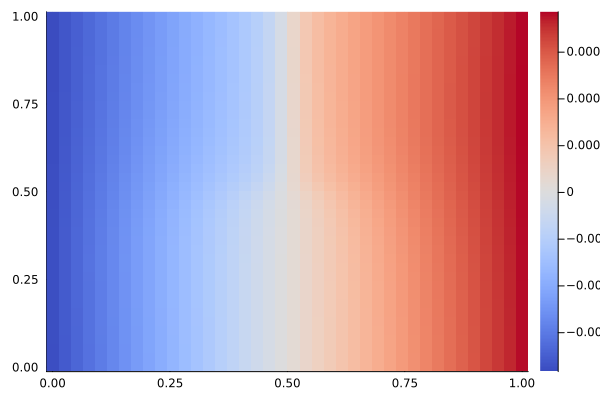

In [139]:
heatmap(x, y, a1', color = :coolwarm,)

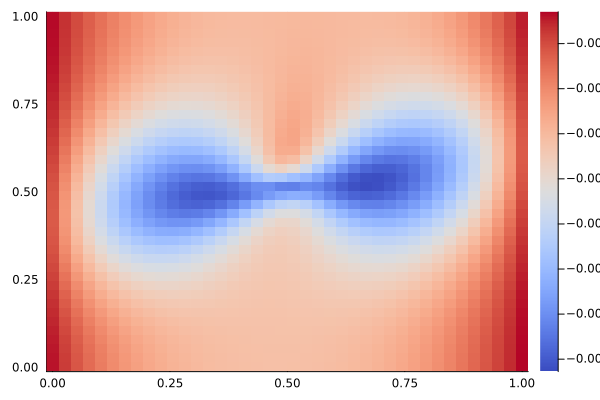

In [140]:
heatmap(x, y, a2', color = :coolwarm,)

In [141]:
a1x = 0.0*similar(a1)
a1y = 0.0*similar(a1)

a2x = 0.0*similar(a2)
a2y = 0.0*similar(a2)

    for j in 1:p.Ny
        for i in 1:p.Nx
            a1x[i,j] = Dx(a1,i,j,p)
            a1y[i,j] = Dy(a1,i,j,p)
            
            a2x[i,j] = Dx(a2,i,j,p)
            a2y[i,j] = Dy(a2,i,j,p)
        end
    end

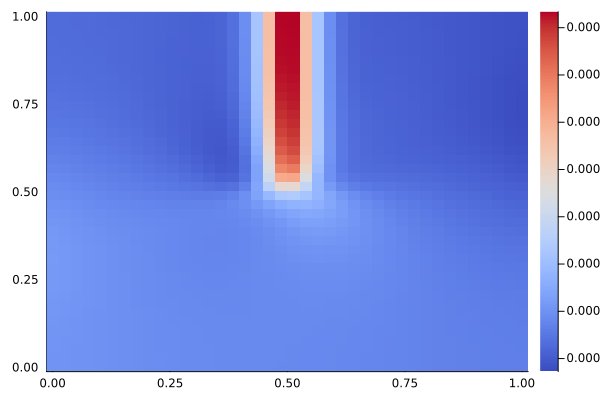

In [142]:
heatmap(x, y, a1x', color = :coolwarm,)

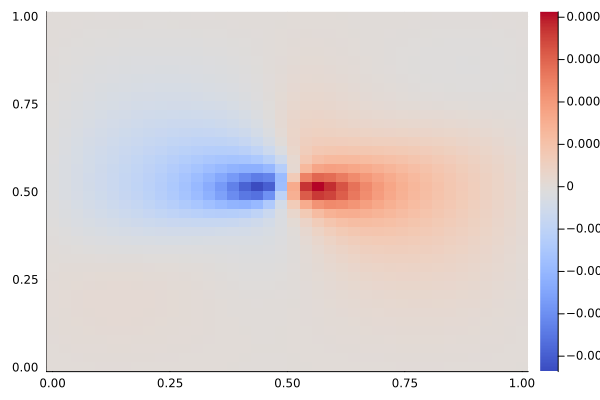

In [143]:
heatmap(x, y, a1y', color = :coolwarm,)

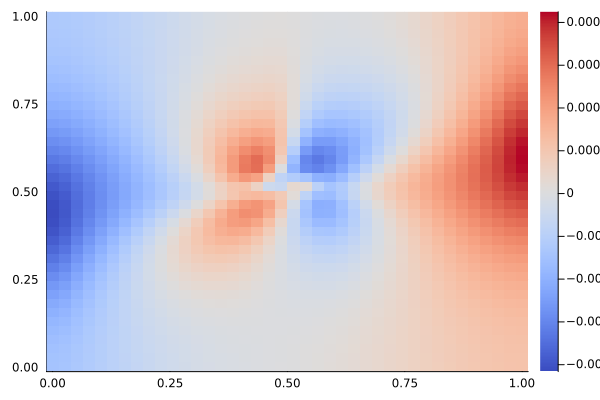

In [144]:
heatmap(x, y, a2x', color = :coolwarm,)

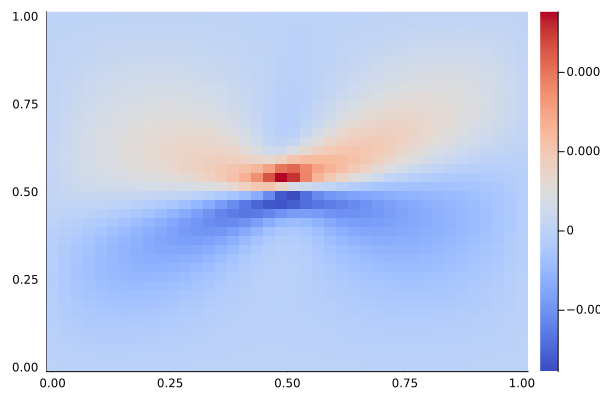

In [145]:
heatmap(x, y, a2y', color = :coolwarm,)

In [30]:
function DDx(x,f)
    Nx = length(x)
    Δx = x[2]-x[1]
    fx = 0.0*copy(f)
    fx[1,:] .= (f[2,:] .- f[1,:]) / Δx
    fx[Nx,:] .= (f[Nx,:] .- f[Nx-1,:]) / Δx
    for i in 2:Nx-1
        fx[i,:].= (f[i+1,:] .- f[i-1,:]) / (2Δx)
    end
    return fx
end

function DDy(y,f)
    Ny = length(y)
    Δy = y[2]-y[1]
    fy = 0.0*copy(f)
    fy[:,1] .= (f[:,2] .- f[:,1]) / Δy
    fy[:,Ny] .=  (f[:,Ny] .- f[:,Ny-1]) / Δy
    for j in 2:Ny-1
        fy[:,j] .= (f[:,j+1] .- f[:,j-1]) / (2Δy)
    end
    return fy
end

DDy (generic function with 1 method)

In [31]:
Da1x = DDx(x,a1)
Da1y = DDy(y,a1)

Da2x = DDx(x,a2)
Da2y = DDy(y,a2)

40×40 Matrix{Float64}:
  4.56399e-16   7.73852e-16   3.27158e-15  …  -7.30191e-16   3.29361e-16
 -1.21537e-5   -8.13875e-6   -2.68353e-6      -1.58474e-5   -2.26847e-5
 -8.54625e-6   -8.13444e-6   -5.8554e-6       -1.05334e-5   -1.04085e-5
 -9.15571e-6   -8.66172e-6   -6.94817e-6      -1.10208e-5   -1.13944e-5
 -8.60697e-6   -8.51895e-6   -7.60412e-6      -9.76548e-6   -9.42669e-6
 -8.39328e-6   -8.38739e-6   -7.86556e-6   …  -9.20434e-6   -8.88005e-6
 -8.13426e-6   -8.20758e-6   -7.96519e-6      -8.60498e-6   -8.20341e-6
 -7.92967e-6   -8.03793e-6   -7.96745e-6      -8.16705e-6   -7.76741e-6
 -7.74556e-6   -7.87698e-6   -7.92222e-6      -7.80339e-6   -7.4046e-6
 -7.5838e-6    -7.72892e-6   -7.85241e-6      -7.51769e-6   -7.13148e-6
 -7.4381e-6    -7.59276e-6   -7.77177e-6   …  -7.29051e-6   -6.91922e-6
 -7.30586e-6   -7.46773e-6   -7.68777e-6      -7.11334e-6   -6.75916e-6
 -7.18474e-6   -7.35283e-6   -7.60479e-6      -6.9774e-6    -6.64079e-6
  ⋮                                      

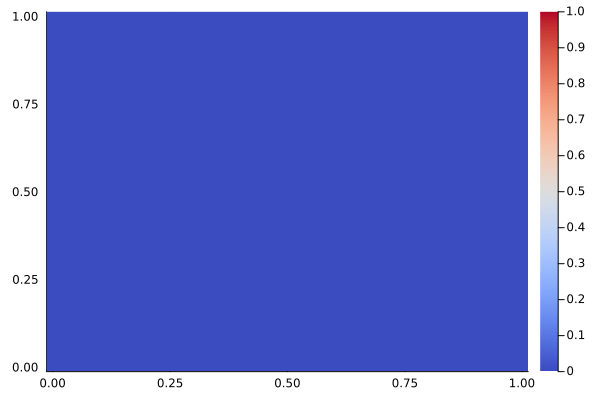

In [38]:
heatmap(x, y, (Da1x .-a1x)', color = :coolwarm,)

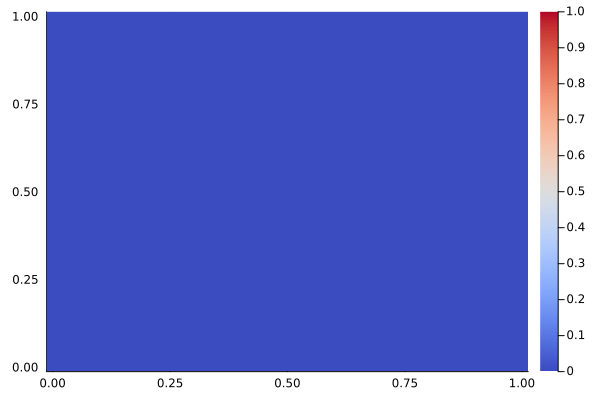

In [37]:
heatmap(x, y, (Da1y .-a1y)', color = :coolwarm,)

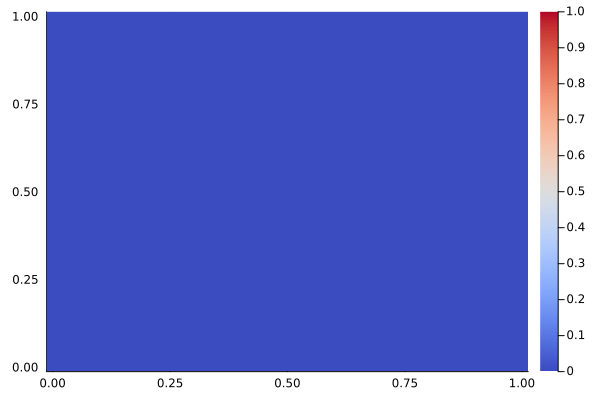

In [34]:
heatmap(x, y, (Da2x .-a2x)', color = :coolwarm,)

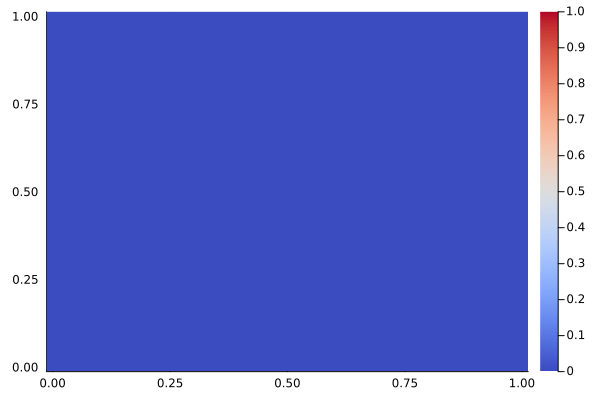

In [35]:
heatmap(x, y, (Da2y.-a2y)', color = :coolwarm,)